# AgriCast360 - Time Series Analysis: Temporal Patterns & Seasonality

**Objective:** Analyze temporal patterns and seasonality in agricultural price data to understand:
1. **Seasonal Trends:** How do prices vary across different seasons and months?
2. **Time-Based Patterns:** Are there weekly, monthly, or yearly patterns?
3. **Decomposition:** Break down time series into trend, seasonal, and residual components
4. **Autocorrelation:** How do prices correlate with their past values?
5. **Stationarity:** Is the series stationary or does it require transformation?
6. **Forecasting Insights:** What patterns can inform predictive models?

**Data Sources:**
- Combined Mandi Data with price information
- Combined Weather Data
- Features from Features_building.ipynb

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from datetime import datetime

# Time series specific imports
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from scipy import stats

# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 8)
pd.set_option('display.max_columns', None)

# Define Paths
ROOT_FOLDER = Path(r"D:\CUDA_Experiments\Git_HUB\Machine-Learning\AgriCast360\AgriCast360_V2")
EDA_RESULTS_FOLDER = ROOT_FOLDER / "EDA_Results"
MANDI_DATA_PATH = EDA_RESULTS_FOLDER / "Mandi" / "Overall" / "combined_mandi_data.csv"
WEATHER_DATA_PATH = EDA_RESULTS_FOLDER / "Weather" / "Overall" / "combined_weather_data.csv"

print("✅ Libraries imported and paths defined.")

✅ Libraries imported and paths defined.


## 1. Data Loading and Preparation

Load the combined Mandi and Weather data from EDA results.

In [2]:
# Load Combined Mandi Data
print("⏳ Loading Mandi Data...")
df_mandi = pd.read_csv(MANDI_DATA_PATH)
df_mandi['Date'] = pd.to_datetime(df_mandi['Arrival_Date'])

print(f"✅ Mandi Data Loaded: {df_mandi.shape}")
print(f"   Date Range: {df_mandi['Date'].min()} to {df_mandi['Date'].max()}")
print(f"   Locations: {df_mandi['Source_Mandi'].unique()}")
print(f"   Commodities: {df_mandi['Commodity'].nunique()}")

# Load Combined Weather Data
print("\n⏳ Loading Weather Data...")
df_weather = pd.read_csv(WEATHER_DATA_PATH)
df_weather['Date'] = pd.to_datetime(df_weather['datetime'])

print(f"✅ Weather Data Loaded: {df_weather.shape}")
print(f"   Date Range: {df_weather['Date'].min()} to {df_weather['Date'].max()}")
print(f"   Locations: {df_weather['Source_Location'].nunique()}")

# Display sample
print("\n📊 Mandi Data Sample:")
display(df_mandi.head())

print("\n🌦️  Weather Data Sample:")
display(df_weather.head())

⏳ Loading Mandi Data...
✅ Mandi Data Loaded: (84549, 12)
   Date Range: 2023-01-01 00:00:00 to 2024-12-31 00:00:00
   Locations: ['Ahmedabad' 'Amreli' 'Surat']
   Commodities: 94

⏳ Loading Weather Data...
✅ Weather Data Loaded: (11820, 59)
   Date Range: 2024-01-01 00:00:00 to 2024-12-12 00:00:00
   Locations: 33

📊 Mandi Data Sample:


,State,District,Market,Commodity,Variety,Arrival_Date,Min_Price,Max_Price,Modal_Price,Commodity_Code,Source_Mandi,Date
0,Gujarat,Ahmedabad,Ahmedabad (Vasana),Cabbage,Other,2024-07-08,1200,3300,2950,154,Ahmedabad,2024-07-08
1,Gujarat,Ahmedabad,Ahmedabad (Vasana),Cabbage,Other,2024-07-10,1500,3800,3050,154,Ahmedabad,2024-07-10
2,Gujarat,Ahmedabad,Ahmedabad (Vasana),Cabbage,Other,2024-07-13,2000,3800,3100,154,Ahmedabad,2024-07-13
3,Gujarat,Ahmedabad,Ahmedabad (Vasana),Cabbage,Other,2024-07-26,1200,2800,2150,154,Ahmedabad,2024-07-26
4,Gujarat,Ahmedabad,Ahmedabad (Vasana),Cabbage,Other,2024-07-30,1500,2500,2050,154,Ahmedabad,2024-07-30



🌦️  Weather Data Sample:


,clouds (%),Date,dewpt (°C),dhi (W/m²),dni (W/m²),ghi (W/m²),max_dhi (W/m²),max_dni (W/m²),max_ghi (W/m²),max_temp (°C),max_uv (Index),max_wind_dir (°),max_wind_spd (m/s),min_temp (°C),precip (mm),precip_gpm (mm/hr),pres (hPa),rh (%),slp (hPa),solar_rad (W/m²),temp (°C),wind_dir (°),wind_gust_spd (m/s),wind_spd (m/s),market_name (Text),query_lat (°),query_lon (°),Source_Location,clouds,datetime,dewpt,dhi,dni,ghi,max_dhi,max_dni,max_ghi,max_temp,max_uv,max_wind_dir,max_wind_spd,min_temp,precip,precip_gpm,pres,rh,slp,solar_rad,t_dhi,t_dni,t_ghi,t_solar_rad,temp,ts,wind_dir,wind_gust_spd,wind_spd,Market,Date
0,0.00,2024-01-01,15.8,40.0,331.0,204.0,114.0,901.0,730.0,27.4,5.8,89.0,3.8,15.2,0.0,0.0,1009.0,0.74,1014.0,204.0,20.9,89.0,4.8,2.1,Ahmedabad_Chimanbhai_Patal_Market_Vasana,22.996977,72.536392,Ahmedabad_(Vasana),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
1,0.01,2024-02-01,15.3,40.0,331.0,205.0,114.0,902.0,731.0,25.0,5.9,61.0,4.1,16.0,0.0,0.0,1009.0,0.75,1014.0,205.0,20.0,61.0,6.0,2.7,Ahmedabad_Chimanbhai_Patal_Market_Vasana,22.996977,72.536392,Ahmedabad_(Vasana),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
2,0.01,2024-03-01,12.5,40.0,331.0,205.0,114.0,902.0,733.0,26.0,5.7,88.0,4.5,14.0,0.0,0.0,1008.0,0.67,1013.0,205.0,19.5,88.0,6.8,2.9,Ahmedabad_Chimanbhai_Patal_Market_Vasana,22.996977,72.536392,Ahmedabad_(Vasana),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
3,0.00,2024-04-01,11.9,40.0,332.0,206.0,114.0,903.0,734.0,25.6,5.9,78.0,5.0,14.0,0.0,0.0,1009.0,0.67,1014.0,206.0,18.8,78.0,7.6,3.1,Ahmedabad_Chimanbhai_Patal_Market_Vasana,22.996977,72.536392,Ahmedabad_(Vasana),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
4,0.15,2024-05-01,10.5,40.0,332.0,207.0,114.0,903.0,736.0,25.4,5.9,86.0,4.6,13.0,0.0,0.0,1008.0,0.62,1013.0,204.0,18.6,86.0,6.8,2.8,Ahmedabad_Chimanbhai_Patal_Market_Vasana,22.996977,72.536392,Ahmedabad_(Vasana),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT


## 2. Overall Time Series Overview

Visualize the complete price trends across all commodities and locations to identify macro patterns.

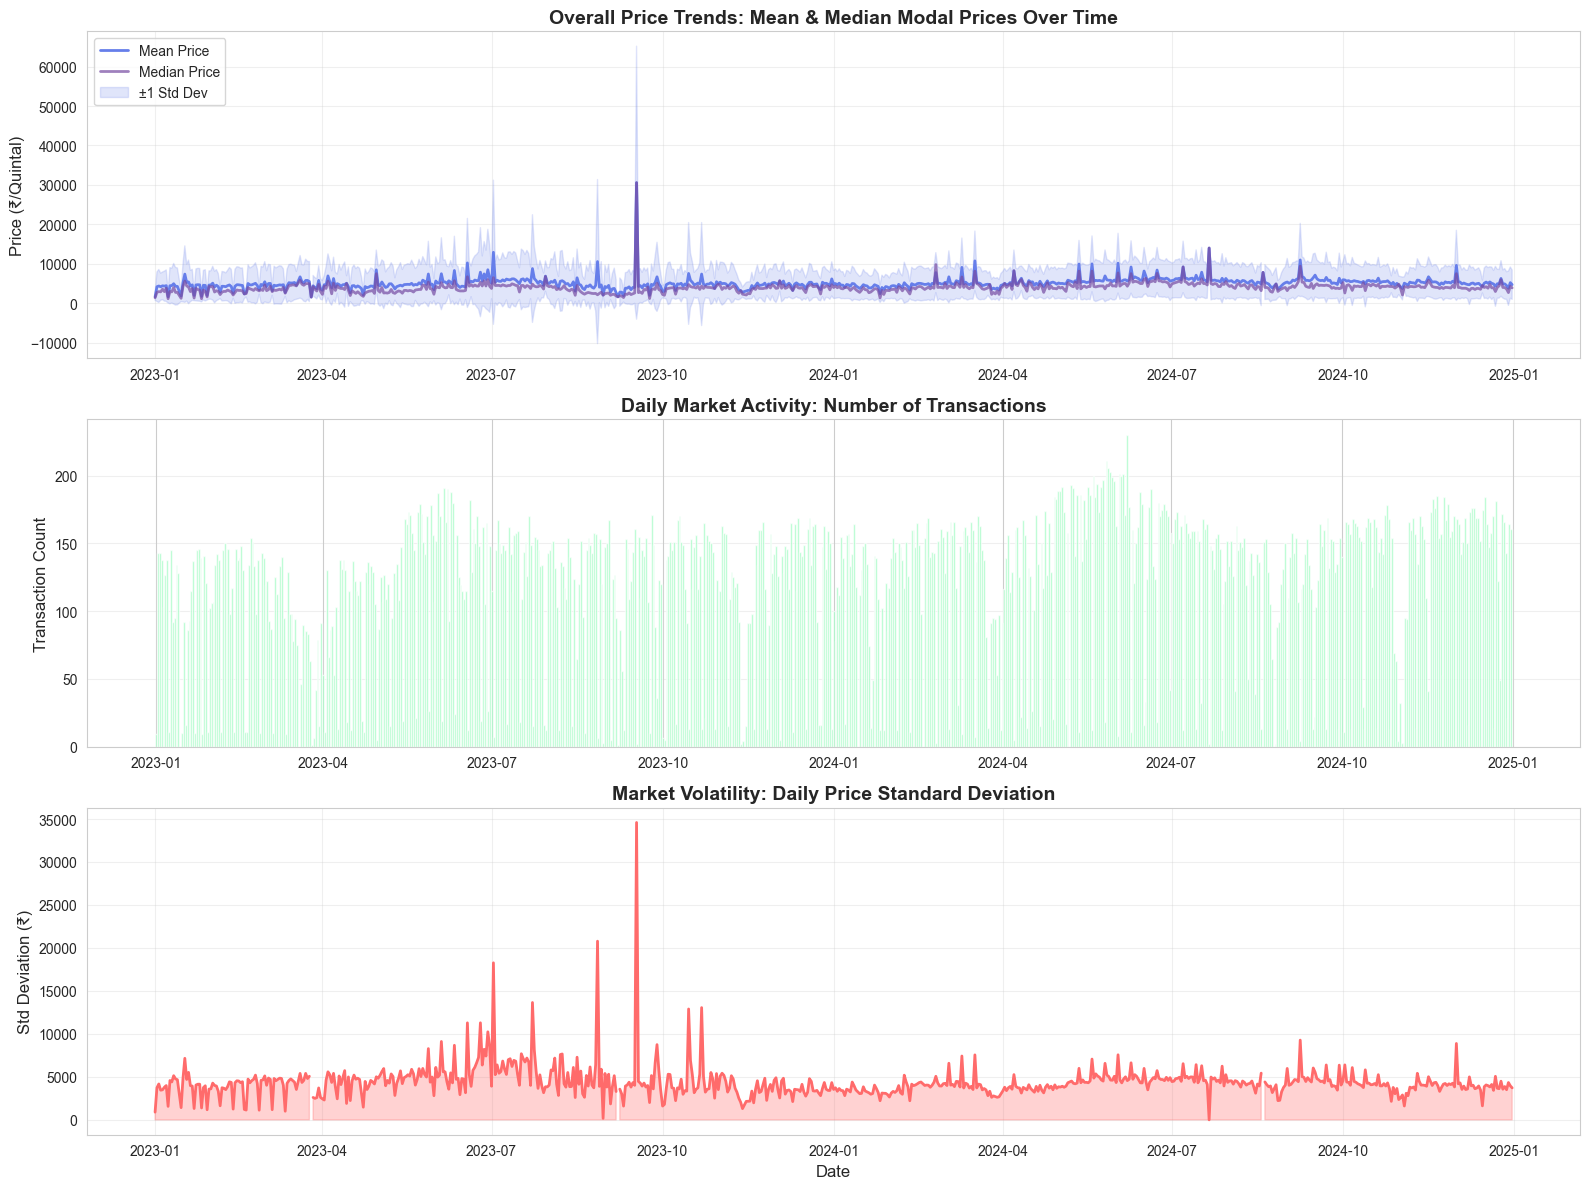

OVERALL TIME SERIES SUMMARY
Date Range: 2023-01-01 to 2024-12-31
Total Days: 722
Average Daily Price: ₹5127.79
Price Range: ₹1562.00 - ₹30562.50
Average Daily Transactions: 117.1
Average Volatility: ±₹4400.27


In [3]:
# Aggregate daily average prices across all commodities and locations
df_daily = df_mandi.groupby('Date').agg({
    'Modal_Price': ['mean', 'median', 'std'],
    'Commodity': 'count'
}).reset_index()

df_daily.columns = ['Date', 'Mean_Price', 'Median_Price', 'Std_Price', 'Transaction_Count']

# Plot overall price trends
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# 1. Mean and Median Prices Over Time
axes[0].plot(df_daily['Date'], df_daily['Mean_Price'], label='Mean Price', linewidth=2, color='#667eea')
axes[0].plot(df_daily['Date'], df_daily['Median_Price'], label='Median Price', linewidth=2, color='#764ba2', alpha=0.7)
axes[0].fill_between(df_daily['Date'], 
                       df_daily['Mean_Price'] - df_daily['Std_Price'], 
                       df_daily['Mean_Price'] + df_daily['Std_Price'], 
                       alpha=0.2, color='#667eea', label='±1 Std Dev')
axes[0].set_title('Overall Price Trends: Mean & Median Modal Prices Over Time', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (₹/Quintal)', fontsize=12)
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# 2. Daily Transaction Volume
axes[1].bar(df_daily['Date'], df_daily['Transaction_Count'], color='#84fab0', alpha=0.7, width=1)
axes[1].set_title('Daily Market Activity: Number of Transactions', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Transaction Count', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

# 3. Price Volatility (Standard Deviation)
axes[2].plot(df_daily['Date'], df_daily['Std_Price'], color='#ff6b6b', linewidth=2)
axes[2].fill_between(df_daily['Date'], df_daily['Std_Price'], alpha=0.3, color='#ff6b6b')
axes[2].set_title('Market Volatility: Daily Price Standard Deviation', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Date', fontsize=12)
axes[2].set_ylabel('Std Deviation (₹)', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary Statistics
print("="*80)
print("OVERALL TIME SERIES SUMMARY")
print("="*80)
print(f"Date Range: {df_daily['Date'].min().strftime('%Y-%m-%d')} to {df_daily['Date'].max().strftime('%Y-%m-%d')}")
print(f"Total Days: {len(df_daily)}")
print(f"Average Daily Price: ₹{df_daily['Mean_Price'].mean():.2f}")
print(f"Price Range: ₹{df_daily['Mean_Price'].min():.2f} - ₹{df_daily['Mean_Price'].max():.2f}")
print(f"Average Daily Transactions: {df_daily['Transaction_Count'].mean():.1f}")
print(f"Average Volatility: ±₹{df_daily['Std_Price'].mean():.2f}")
print("="*80)

## 3. Seasonal Patterns Analysis

Analyze how prices vary by month, quarter, and season to identify agricultural cycles.

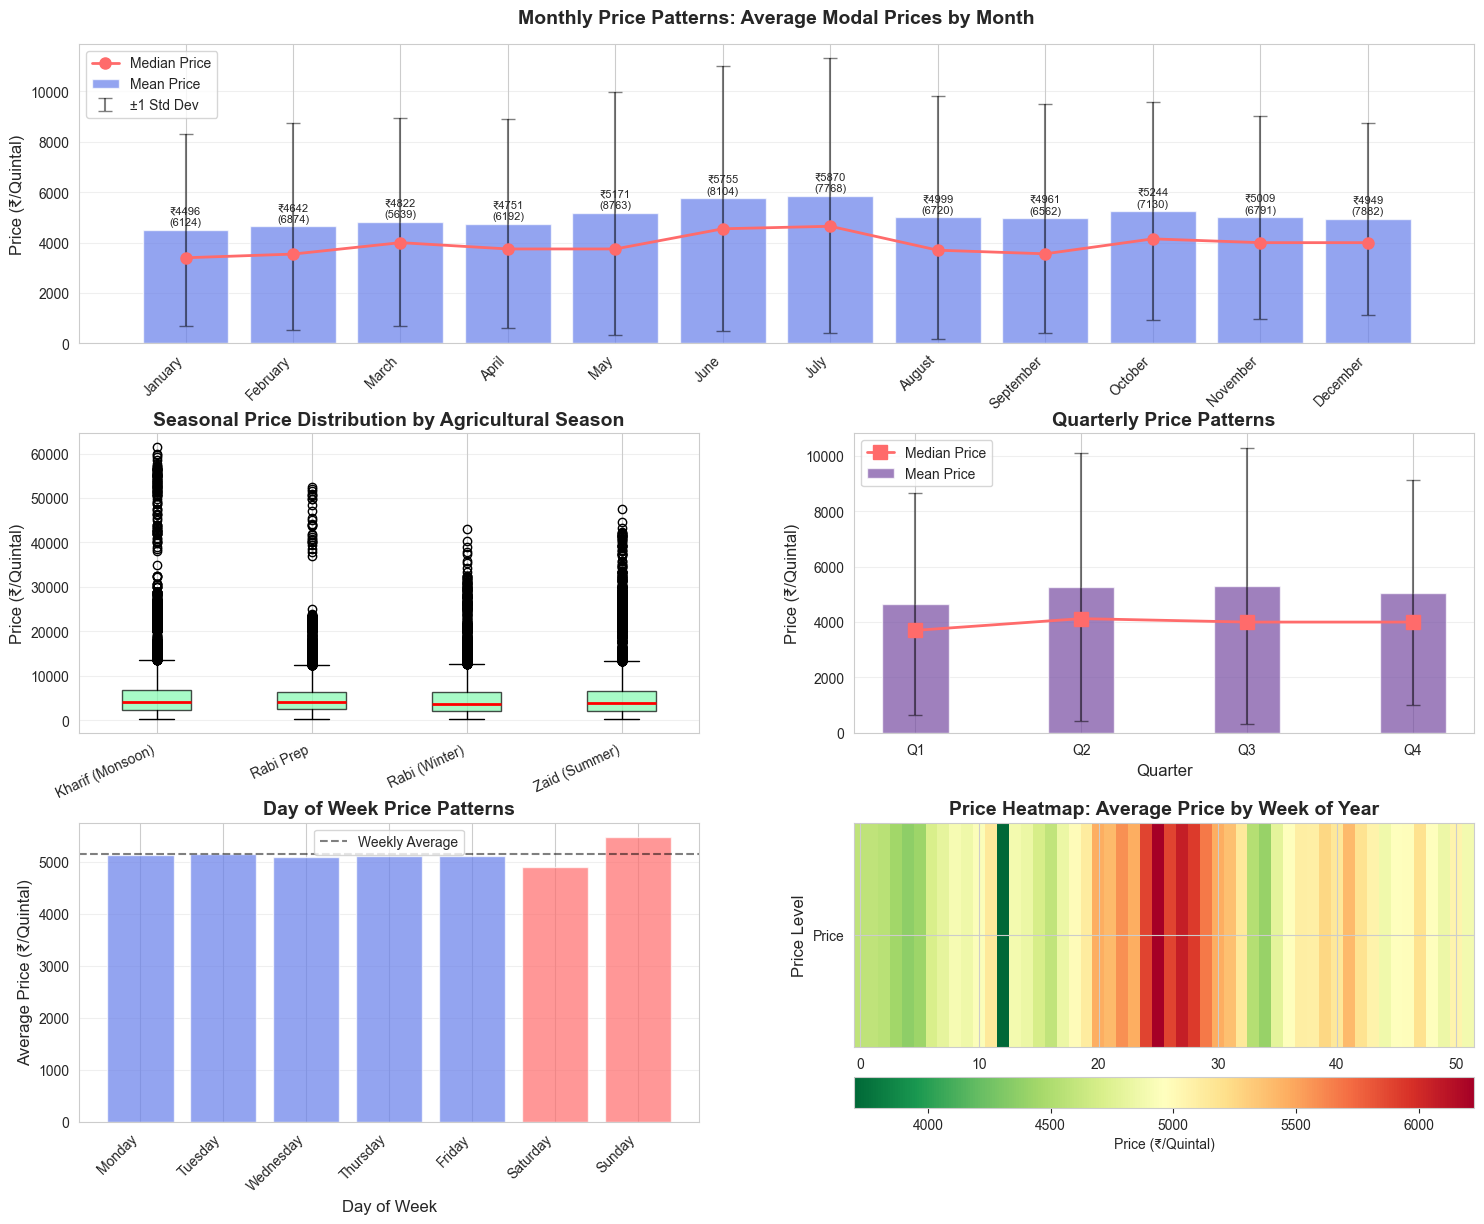


SEASONAL ANALYSIS SUMMARY

📅 Monthly Price Summary:
Month_Name  Mean_Price  Median_Price  Count
   January 4495.976323        3400.0   6124
  February 4641.864708        3546.5   6874
     March 4822.400426        4000.0   5639
     April 4751.268249        3750.0   6192
       May 5170.528814        3750.0   8763
      June 5755.065276        4550.0   8104
      July 5869.621782        4650.0   7768
    August 4999.039286        3700.0   6720
 September 4961.435843        3557.5   6562
   October 5244.372791        4150.0   7130
  November 5008.641584        4000.0   6791
  December 4949.278229        4000.0   7882

🌾 Seasonal Price Summary:
                     Mean  Median      Std  Min    Max  Count
Season                                                       
Kharif (Monsoon)  5432.69  4143.5  5078.37  300  61500  29154
Rabi (Winter)     4715.12  3750.0  3912.29  300  43125  20880
Rabi Prep         5129.38  4000.0  4189.46  300  52500  13921
Zaid (Summer)     4949.15  3850.0  444

In [4]:
# Add temporal features to Mandi data
df_mandi['Year'] = df_mandi['Date'].dt.year
df_mandi['Month'] = df_mandi['Date'].dt.month
df_mandi['Month_Name'] = df_mandi['Date'].dt.strftime('%B')
df_mandi['Quarter'] = df_mandi['Date'].dt.quarter
df_mandi['DayOfWeek'] = df_mandi['Date'].dt.dayofweek
df_mandi['DayOfWeek_Name'] = df_mandi['Date'].dt.strftime('%A')
df_mandi['WeekOfYear'] = df_mandi['Date'].dt.isocalendar().week

# Define agricultural seasons for Gujarat
def get_season(month):
    if month in [6, 7, 8, 9]:  # Monsoon/Kharif
        return 'Kharif (Monsoon)'
    elif month in [10, 11]:  # Post-Monsoon
        return 'Rabi Prep'
    elif month in [12, 1, 2]:  # Winter/Rabi
        return 'Rabi (Winter)'
    else:  # Summer
        return 'Zaid (Summer)'

df_mandi['Season'] = df_mandi['Month'].apply(get_season)

# 1. Monthly Price Patterns
monthly_avg = df_mandi.groupby(['Month', 'Month_Name']).agg({
    'Modal_Price': ['mean', 'median', 'std', 'count']
}).reset_index()
monthly_avg.columns = ['Month', 'Month_Name', 'Mean_Price', 'Median_Price', 'Std_Price', 'Count']
monthly_avg = monthly_avg.sort_values('Month')

# Create comprehensive seasonal visualization
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.25)

# 1. Monthly Average Prices
ax1 = fig.add_subplot(gs[0, :])
x_pos = np.arange(len(monthly_avg))
bars = ax1.bar(x_pos, monthly_avg['Mean_Price'], color='#667eea', alpha=0.7, label='Mean Price')
ax1.errorbar(x_pos, monthly_avg['Mean_Price'], yerr=monthly_avg['Std_Price'], 
             fmt='none', color='black', alpha=0.5, capsize=5, label='±1 Std Dev')
ax1.plot(x_pos, monthly_avg['Median_Price'], color='#ff6b6b', marker='o', 
         linewidth=2, markersize=8, label='Median Price')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(monthly_avg['Month_Name'], rotation=45, ha='right')
ax1.set_title('Monthly Price Patterns: Average Modal Prices by Month', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('Price (₹/Quintal)', fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (price, count) in enumerate(zip(monthly_avg['Mean_Price'], monthly_avg['Count'])):
    ax1.text(i, price + 100, f'₹{price:.0f}\n({count})', ha='center', va='bottom', fontsize=8)

# 2. Seasonal Comparison (Box Plot)
ax2 = fig.add_subplot(gs[1, 0])
season_order = ['Kharif (Monsoon)', 'Rabi Prep', 'Rabi (Winter)', 'Zaid (Summer)']
seasonal_data = [df_mandi[df_mandi['Season'] == s]['Modal_Price'].values for s in season_order]
bp = ax2.boxplot(seasonal_data, labels=season_order, patch_artist=True, 
                 medianprops=dict(color='red', linewidth=2),
                 boxprops=dict(facecolor='#84fab0', alpha=0.7))
ax2.set_title('Seasonal Price Distribution by Agricultural Season', fontsize=14, fontweight='bold')
ax2.set_ylabel('Price (₹/Quintal)', fontsize=12)
ax2.set_xticklabels(season_order, rotation=25, ha='right')
ax2.grid(True, alpha=0.3, axis='y')

# 3. Quarterly Trends
ax3 = fig.add_subplot(gs[1, 1])
quarterly = df_mandi.groupby('Quarter')['Modal_Price'].agg(['mean', 'median', 'std']).reset_index()
x_q = quarterly['Quarter']
ax3.bar(x_q, quarterly['mean'], color='#764ba2', alpha=0.7, width=0.4, label='Mean Price')
ax3.errorbar(x_q, quarterly['mean'], yerr=quarterly['std'], fmt='none', color='black', alpha=0.5, capsize=5)
ax3.plot(x_q, quarterly['median'], color='#ff6b6b', marker='s', linewidth=2, markersize=10, label='Median Price')
ax3.set_xticks(x_q)
ax3.set_xticklabels([f'Q{q}' for q in x_q])
ax3.set_title('Quarterly Price Patterns', fontsize=14, fontweight='bold')
ax3.set_ylabel('Price (₹/Quintal)', fontsize=12)
ax3.set_xlabel('Quarter', fontsize=12)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# 4. Day of Week Analysis
ax4 = fig.add_subplot(gs[2, 0])
dow_avg = df_mandi.groupby(['DayOfWeek', 'DayOfWeek_Name'])['Modal_Price'].mean().reset_index()
dow_avg = dow_avg.sort_values('DayOfWeek')
colors = ['#667eea' if i < 5 else '#ff6b6b' for i in range(len(dow_avg))]
ax4.bar(dow_avg['DayOfWeek_Name'], dow_avg['Modal_Price'], color=colors, alpha=0.7)
ax4.set_title('Day of Week Price Patterns', fontsize=14, fontweight='bold')
ax4.set_ylabel('Average Price (₹/Quintal)', fontsize=12)
ax4.set_xlabel('Day of Week', fontsize=12)
ax4.axhline(y=dow_avg['Modal_Price'].mean(), color='black', linestyle='--', alpha=0.5, label='Weekly Average')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 5. Week of Year Heatmap
ax5 = fig.add_subplot(gs[2, 1])
weekly = df_mandi.groupby('WeekOfYear')['Modal_Price'].mean().reset_index()
weeks_matrix = weekly['Modal_Price'].values.reshape(-1, 1).T
im = ax5.imshow(weeks_matrix, cmap='RdYlGn_r', aspect='auto')
ax5.set_title('Price Heatmap: Average Price by Week of Year', fontsize=14, fontweight='bold')
ax5.set_ylabel('Price Level', fontsize=12)
ax5.set_xlabel('Week of Year', fontsize=12)
ax5.set_yticks([0])
ax5.set_yticklabels(['Price'])
cbar = plt.colorbar(im, ax=ax5, orientation='horizontal', pad=0.1)
cbar.set_label('Price (₹/Quintal)', fontsize=10)

plt.show()

# Print Seasonal Statistics
print("\n" + "="*80)
print("SEASONAL ANALYSIS SUMMARY")
print("="*80)

print("\n📅 Monthly Price Summary:")
print(monthly_avg[['Month_Name', 'Mean_Price', 'Median_Price', 'Count']].to_string(index=False))

print("\n🌾 Seasonal Price Summary:")
seasonal_summary = df_mandi.groupby('Season').agg({
    'Modal_Price': ['mean', 'median', 'std', 'min', 'max', 'count']
}).round(2)
seasonal_summary.columns = ['Mean', 'Median', 'Std', 'Min', 'Max', 'Count']
print(seasonal_summary)

print("\n📊 Key Insights:")
highest_month = monthly_avg.loc[monthly_avg['Mean_Price'].idxmax()]
lowest_month = monthly_avg.loc[monthly_avg['Mean_Price'].idxmin()]
print(f"• Highest average price month: {highest_month['Month_Name']} (₹{highest_month['Mean_Price']:.2f})")
print(f"• Lowest average price month: {lowest_month['Month_Name']} (₹{lowest_month['Mean_Price']:.2f})")
print(f"• Price variation: {((highest_month['Mean_Price'] - lowest_month['Mean_Price']) / lowest_month['Mean_Price'] * 100):.1f}%")

print("="*80)

## 4. Commodity-Specific Time Series Analysis

Deep dive into individual commodities to understand their unique temporal patterns.

Top 10 Commodities by Data Availability:
  1. Wheat: 4369 records
  2. Til: 3710 records
  3. Cotton: 3668 records
  4. Groundnut: 3536 records
  5. Bhindi: 2722 records
  6. Bengal Gram: 2633 records
  7. Potato: 2132 records
  8. Paddy(Dhan): 2118 records
  9. Soyabean: 2085 records
  10. Brinjal: 2047 records


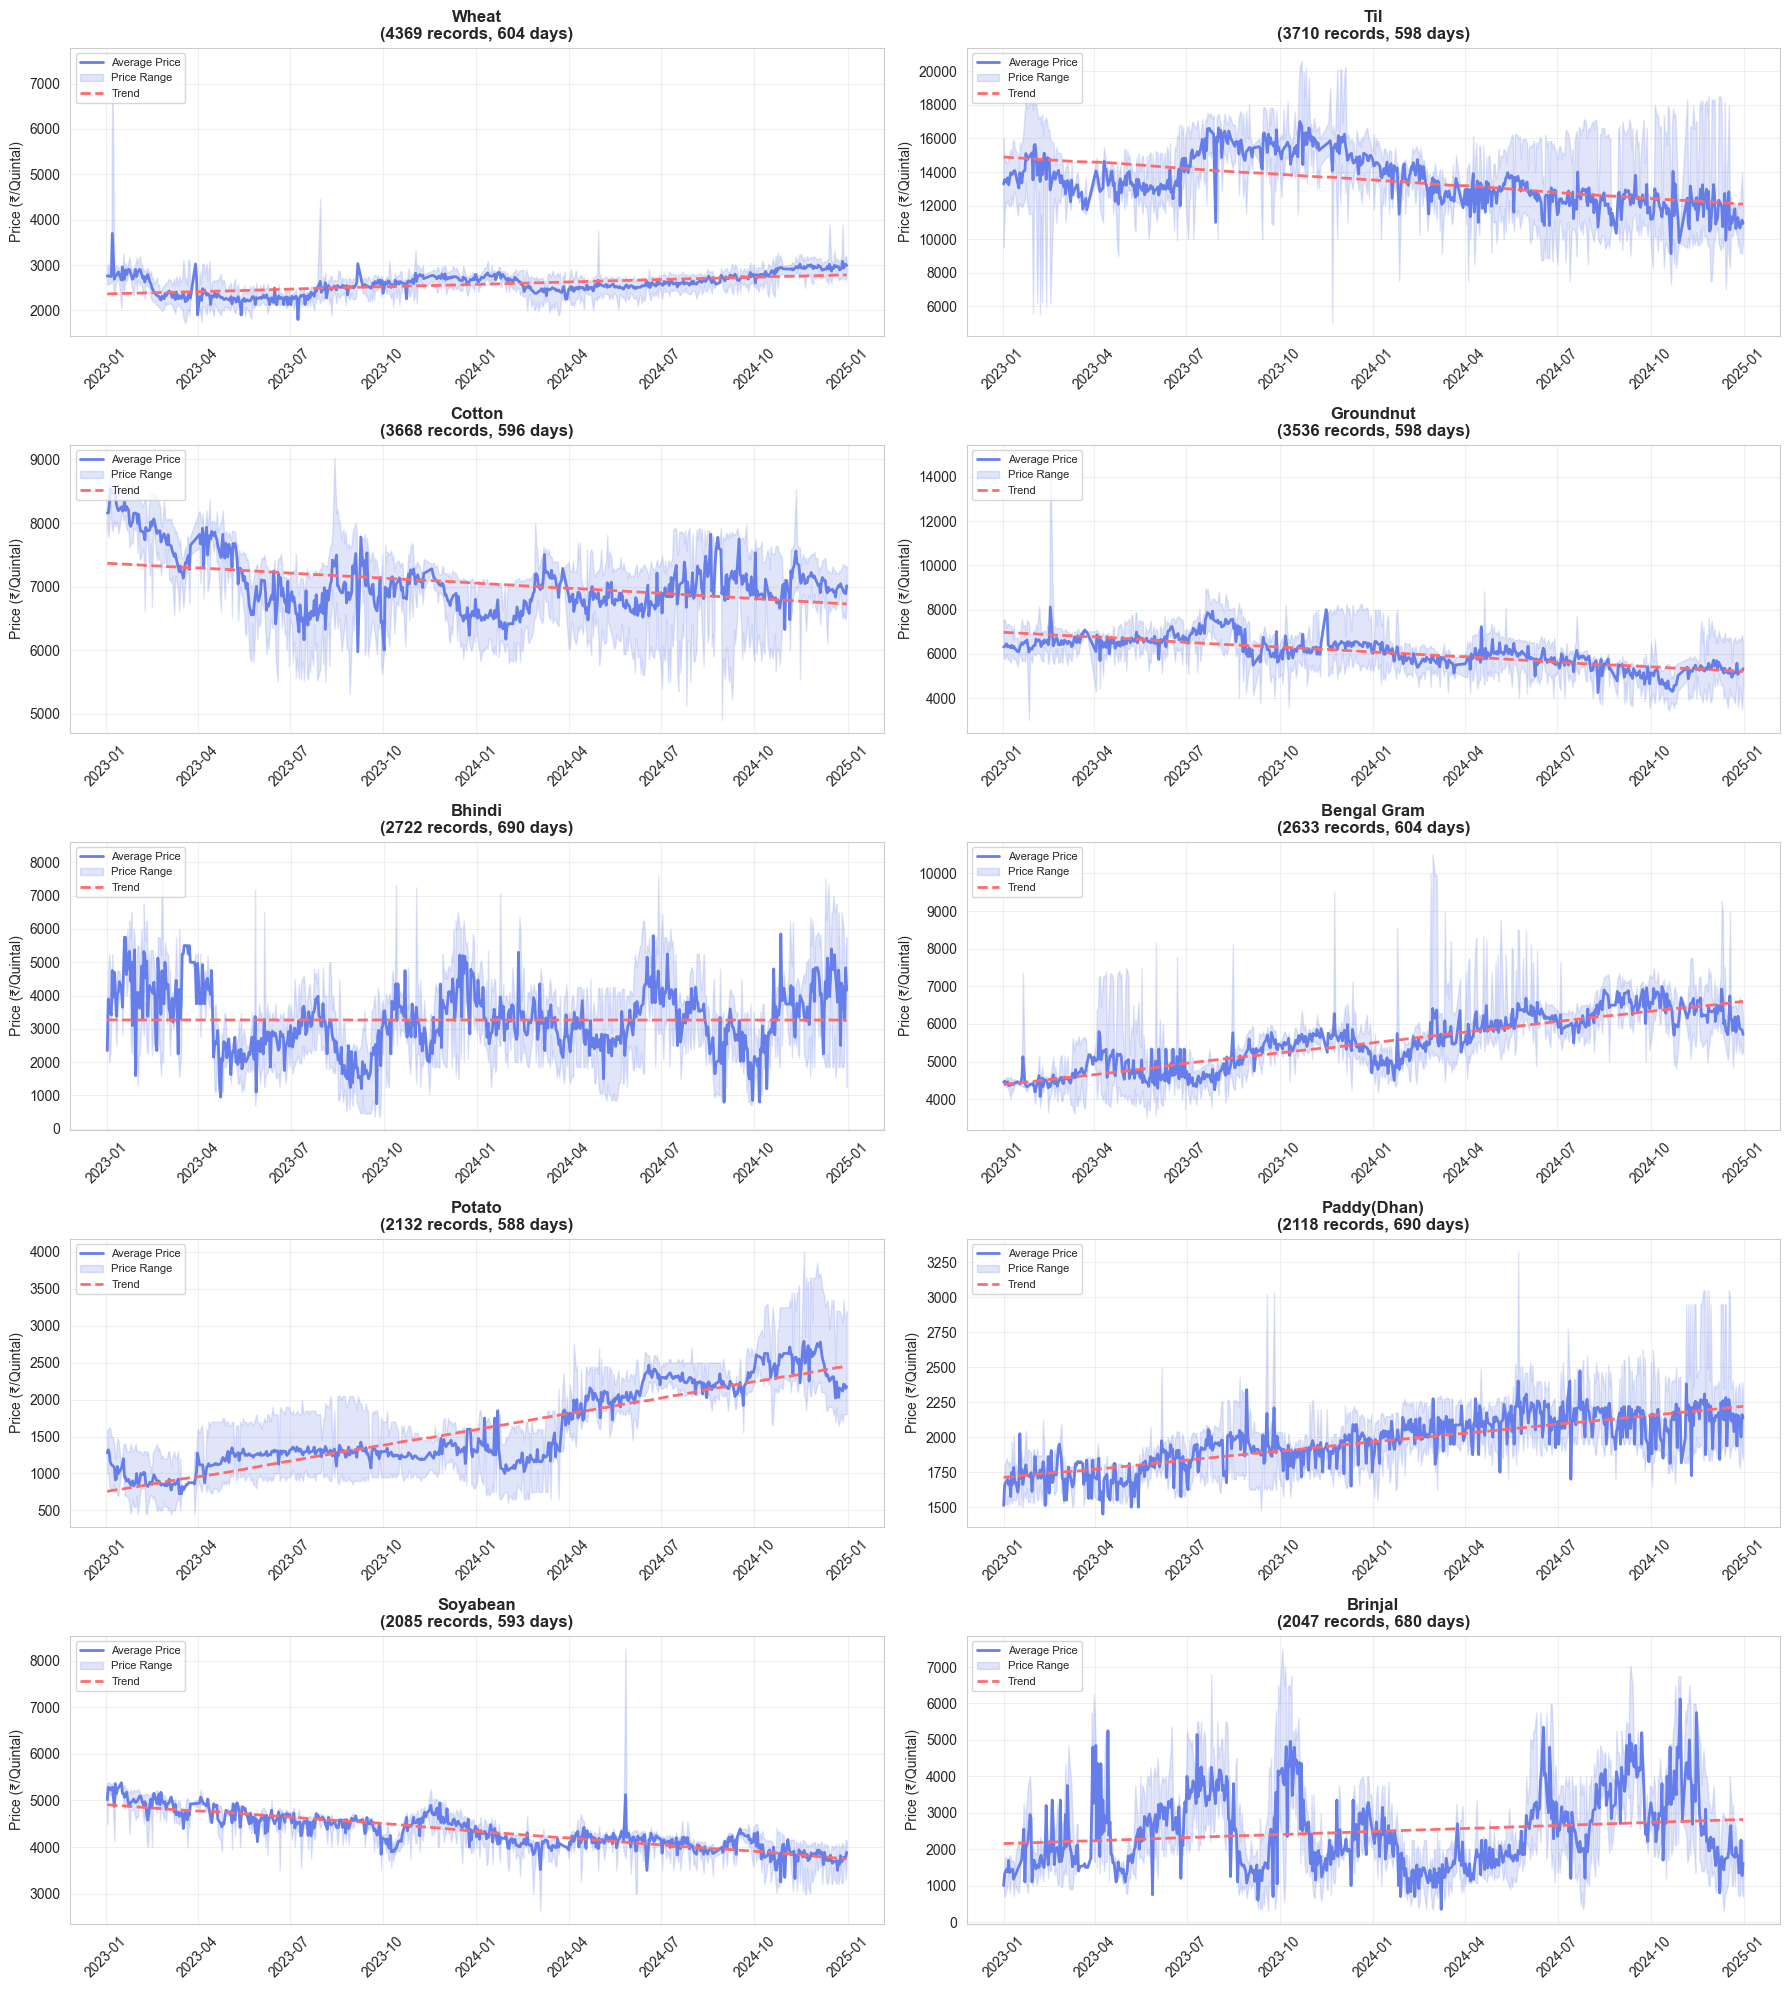


COMMODITY-SPECIFIC SEASONALITY

Wheat:
  Average Price: ₹2595.15
  Price Range: ₹1720.00 - ₹7500.00
  Highest Price Month: November (₹2863.07)
  Lowest Price Month: March (₹2398.82)
  Seasonal Variation: 19.4%

Til:
  Average Price: ₹13522.96
  Price Range: ₹5000.00 - ₹20625.00
  Highest Price Month: August (₹14056.22)
  Lowest Price Month: March (₹12786.99)
  Seasonal Variation: 9.9%

Cotton:
  Average Price: ₹7013.43
  Price Range: ₹4900.00 - ₹9025.00
  Highest Price Month: January (₹7265.27)
  Lowest Price Month: June (₹6784.03)
  Seasonal Variation: 7.1%


In [12]:
# Select top commodities by data availability
top_commodities = df_mandi['Commodity'].value_counts().head(10).index.tolist()

print("Top 10 Commodities by Data Availability:")
for i, commodity in enumerate(top_commodities, 1):
    count = df_mandi[df_mandi['Commodity'] == commodity].shape[0]
    print(f"  {i}. {commodity}: {count} records")

# Create time series for each commodity
fig, axes = plt.subplots(5, 2, figsize=(18, 20))
axes = axes.flatten()

for idx, commodity in enumerate(top_commodities):
    df_commodity = df_mandi[df_mandi['Commodity'] == commodity].copy()
    df_commodity = df_commodity.sort_values('Date')
    
    # Aggregate by date
    commodity_daily = df_commodity.groupby('Date').agg({
        'Modal_Price': ['mean', 'min', 'max']
    }).reset_index()
    commodity_daily.columns = ['Date', 'Mean_Price', 'Min_Price', 'Max_Price']
    
    # Plot
    axes[idx].plot(commodity_daily['Date'], commodity_daily['Mean_Price'], 
                   linewidth=2, color='#667eea', label='Average Price')
    axes[idx].fill_between(commodity_daily['Date'], 
                            commodity_daily['Min_Price'], 
                            commodity_daily['Max_Price'], 
                            alpha=0.2, color='#667eea', label='Price Range')
    
    # Add trend line
    z = np.polyfit(range(len(commodity_daily)), commodity_daily['Mean_Price'], 1)
    p = np.poly1d(z)
    axes[idx].plot(commodity_daily['Date'], p(range(len(commodity_daily))), 
                   '--', color='#ff6b6b', linewidth=2, label=f'Trend')
    
    axes[idx].set_title(f'{commodity}\n({len(df_commodity)} records, {len(commodity_daily)} days)', 
                        fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Price (₹/Quintal)', fontsize=10)
    axes[idx].legend(loc='upper left', fontsize=8)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Commodity Seasonality Comparison
print("\n" + "="*80)
print("COMMODITY-SPECIFIC SEASONALITY")
print("="*80)

for commodity in top_commodities[:3]:  # Detailed analysis for top 3
    df_commodity = df_mandi[df_mandi['Commodity'] == commodity]
    monthly_pattern = df_commodity.groupby('Month_Name')['Modal_Price'].mean().reindex(
        ['January', 'February', 'March', 'April', 'May', 'June', 
         'July', 'August', 'September', 'October', 'November', 'December']
    )
    
    print(f"\n{commodity}:")
    print(f"  Average Price: ₹{df_commodity['Modal_Price'].mean():.2f}")
    print(f"  Price Range: ₹{df_commodity['Modal_Price'].min():.2f} - ₹{df_commodity['Modal_Price'].max():.2f}")
    print(f"  Highest Price Month: {monthly_pattern.idxmax()} (₹{monthly_pattern.max():.2f})")
    print(f"  Lowest Price Month: {monthly_pattern.idxmin()} (₹{monthly_pattern.min():.2f})")
    print(f"  Seasonal Variation: {((monthly_pattern.max() - monthly_pattern.min()) / monthly_pattern.min() * 100):.1f}%")

print("="*80)

## 5. Time Series Decomposition

Decompose the time series into trend, seasonal, and residual components using STL (Seasonal and Trend decomposition using Loess).

Time Series for Decomposition:
  Date Range: 2023-01-01 00:00:00 to 2024-12-31 00:00:00
  Total Days: 731
  Frequency: Daily

⏳ Performing seasonal decomposition...


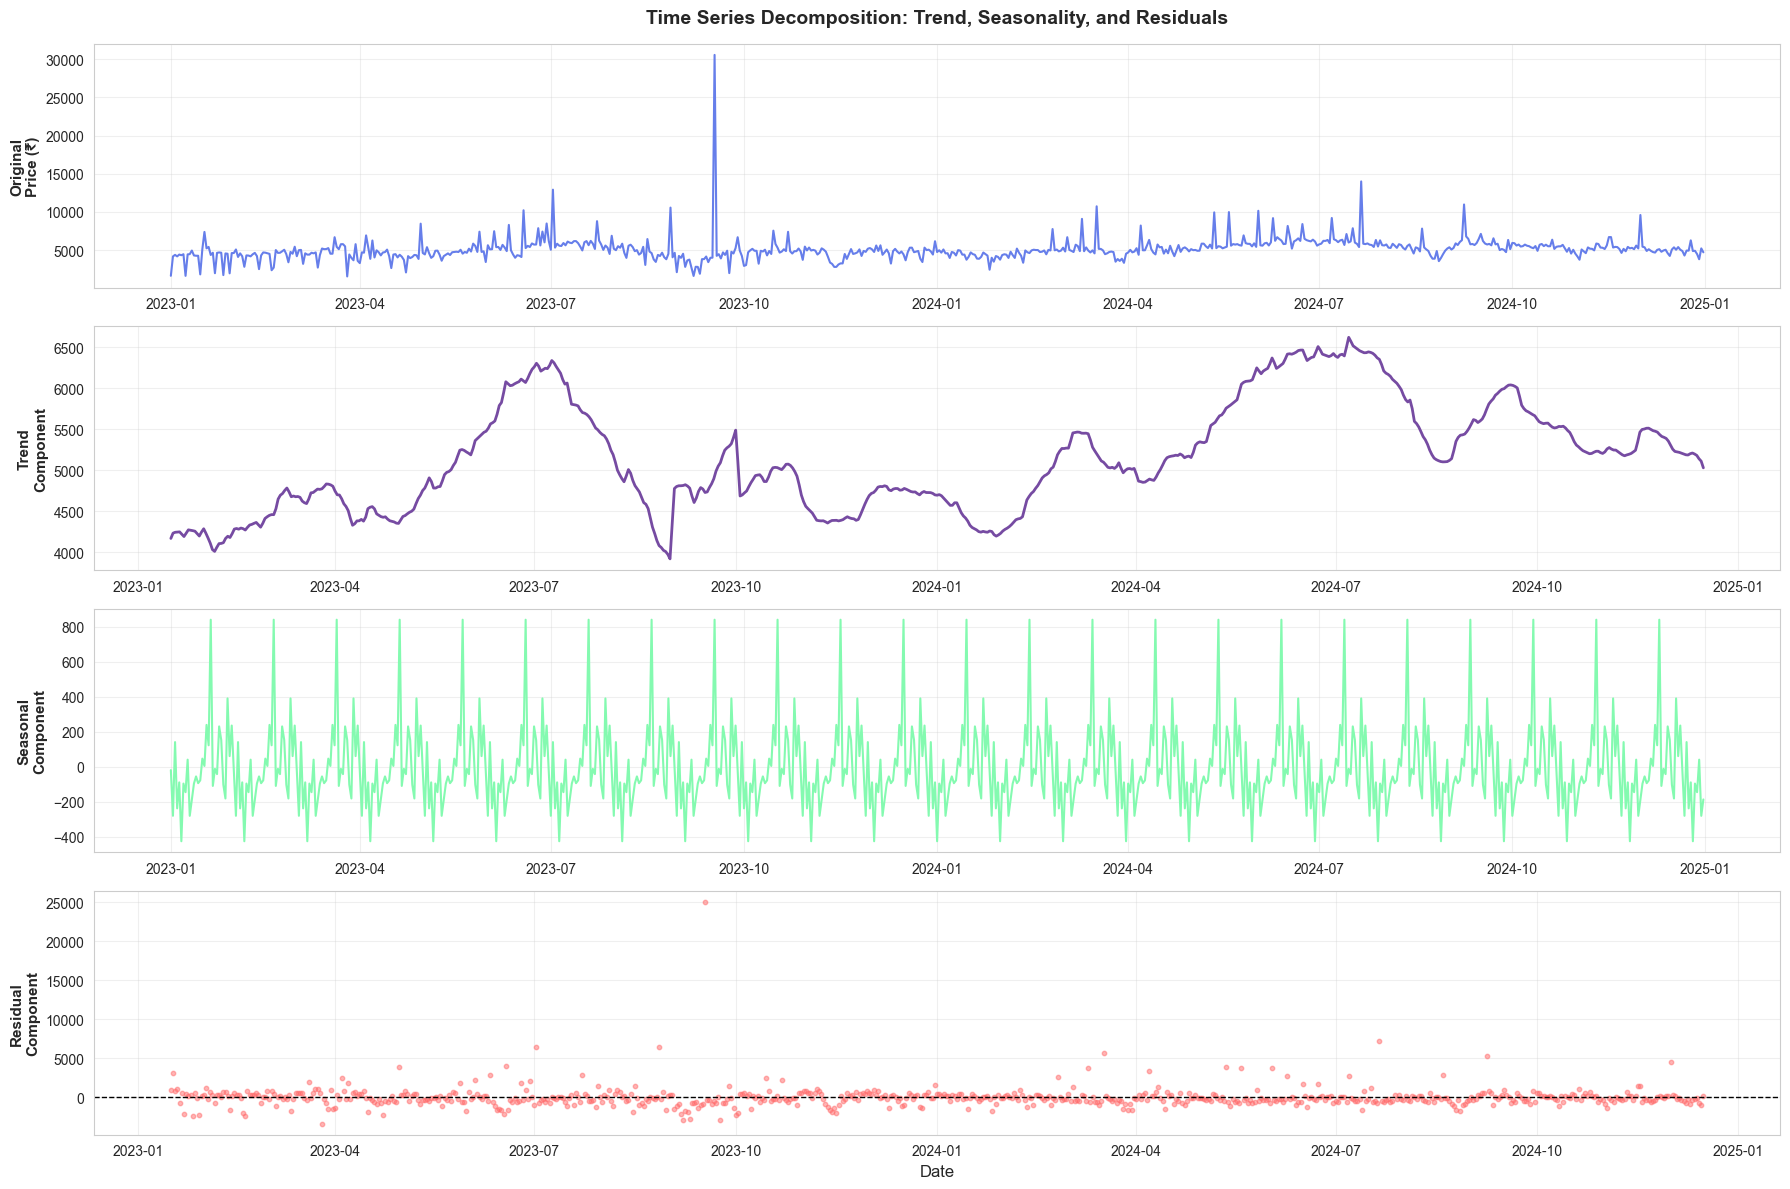


DECOMPOSITION ANALYSIS

📈 Trend Component:
  Overall Trend Direction: Increasing
  Trend Change: 20.71%
  Average Trend Value: ₹5148.87

🔄 Seasonal Component:
  Seasonality Strength: ±₹233.93
  Max Seasonal Effect: +₹841.44
  Min Seasonal Effect: -₹-424.98
  Seasonal Range: ₹1266.41

📊 Residual Component:
  Residual Mean: ₹1.85
  Residual Std Dev: ±₹1405.39
  Residual Range: ₹-3365.08 to ₹24992.88

📉 Variance Decomposition:
  Total Variance: 2430034.80
  Trend Variance: 429707.73 (17.7%)
  Seasonal Variance: 54724.56 (2.3%)
  Residual Variance: 1975114.01 (81.3%)


In [6]:
# Prepare data for decomposition - aggregate overall prices
df_decomp = df_mandi.groupby('Date')['Modal_Price'].mean().reset_index()
df_decomp = df_decomp.set_index('Date').asfreq('D')  # Daily frequency
df_decomp = df_decomp.fillna(method='ffill')  # Forward fill missing dates

print(f"Time Series for Decomposition:")
print(f"  Date Range: {df_decomp.index.min()} to {df_decomp.index.max()}")
print(f"  Total Days: {len(df_decomp)}")
print(f"  Frequency: Daily")

# Perform Seasonal Decomposition (Additive Model)
print("\n⏳ Performing seasonal decomposition...")
decomposition = seasonal_decompose(df_decomp['Modal_Price'], model='additive', period=30)

# Plot decomposition
fig, axes = plt.subplots(4, 1, figsize=(18, 12))

# Original Series
axes[0].plot(df_decomp.index, df_decomp['Modal_Price'], color='#667eea', linewidth=1.5)
axes[0].set_ylabel('Original\nPrice (₹)', fontsize=11, fontweight='bold')
axes[0].set_title('Time Series Decomposition: Trend, Seasonality, and Residuals', 
                  fontsize=14, fontweight='bold', pad=15)
axes[0].grid(True, alpha=0.3)

# Trend Component
axes[1].plot(decomposition.trend.index, decomposition.trend, color='#764ba2', linewidth=2)
axes[1].set_ylabel('Trend\nComponent', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Seasonal Component
axes[2].plot(decomposition.seasonal.index, decomposition.seasonal, color='#84fab0', linewidth=1.5)
axes[2].set_ylabel('Seasonal\nComponent', fontsize=11, fontweight='bold')
axes[2].grid(True, alpha=0.3)

# Residual Component
axes[3].scatter(decomposition.resid.index, decomposition.resid, color='#ff6b6b', alpha=0.5, s=10)
axes[3].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[3].set_ylabel('Residual\nComponent', fontsize=11, fontweight='bold')
axes[3].set_xlabel('Date', fontsize=12)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analyze Decomposition Components
print("\n" + "="*80)
print("DECOMPOSITION ANALYSIS")
print("="*80)

print("\n📈 Trend Component:")
trend_data = decomposition.trend.dropna()
print(f"  Overall Trend Direction: {'Increasing' if trend_data.iloc[-1] > trend_data.iloc[0] else 'Decreasing'}")
print(f"  Trend Change: {((trend_data.iloc[-1] - trend_data.iloc[0]) / trend_data.iloc[0] * 100):.2f}%")
print(f"  Average Trend Value: ₹{trend_data.mean():.2f}")

print("\n🔄 Seasonal Component:")
seasonal_data = decomposition.seasonal
print(f"  Seasonality Strength: ±₹{seasonal_data.std():.2f}")
print(f"  Max Seasonal Effect: +₹{seasonal_data.max():.2f}")
print(f"  Min Seasonal Effect: -₹{seasonal_data.min():.2f}")
print(f"  Seasonal Range: ₹{seasonal_data.max() - seasonal_data.min():.2f}")

print("\n📊 Residual Component:")
residual_data = decomposition.resid.dropna()
print(f"  Residual Mean: ₹{residual_data.mean():.2f}")
print(f"  Residual Std Dev: ±₹{residual_data.std():.2f}")
print(f"  Residual Range: ₹{residual_data.min():.2f} to ₹{residual_data.max():.2f}")

# Calculate variance explained
total_var = df_decomp['Modal_Price'].var()
trend_var = decomposition.trend.dropna().var()
seasonal_var = decomposition.seasonal.var()
residual_var = decomposition.resid.dropna().var()

print("\n📉 Variance Decomposition:")
print(f"  Total Variance: {total_var:.2f}")
print(f"  Trend Variance: {trend_var:.2f} ({trend_var/total_var*100:.1f}%)")
print(f"  Seasonal Variance: {seasonal_var:.2f} ({seasonal_var/total_var*100:.1f}%)")
print(f"  Residual Variance: {residual_var:.2f} ({residual_var/total_var*100:.1f}%)")

print("="*80)

## 6. Autocorrelation Analysis

Analyze how prices correlate with their past values using ACF and PACF plots.

Autocorrelation Analysis
Analyzing 731 data points


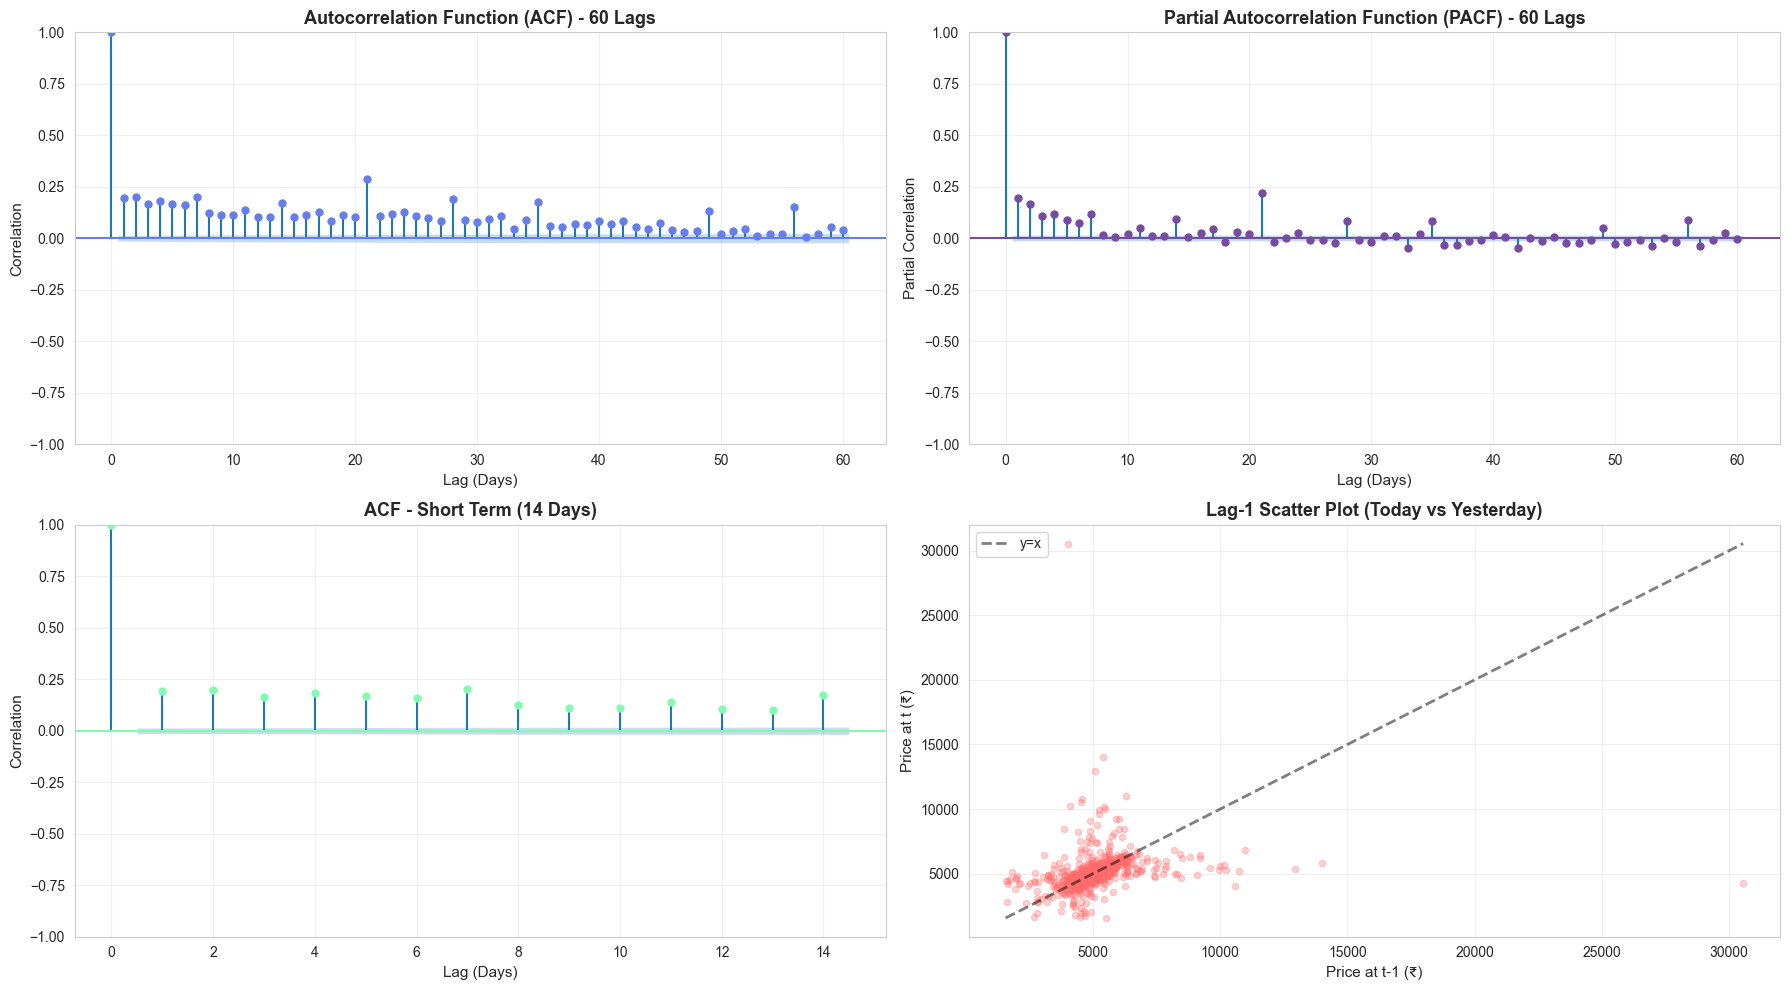


📊 Autocorrelation at Specific Lags:
--------------------------------------------------------------------------------
  Lag  1 (Daily (t-1) ):  0.195
  Lag  3 (3-Day       ):  0.164
  Lag  7 (Weekly      ):  0.202
  Lag 14 (Bi-weekly   ):  0.173
  Lag 21 (3-Week      ):  0.290
  Lag 30 (Monthly     ):  0.081

🔍 Significant Autocorrelations (at 95% confidence):
  Confidence Interval: ±0.072
  Total Significant Lags: 30

  Top 10 Significant Lags:
    Lag 21:  0.290
    Lag  7:  0.202
    Lag  2:  0.199
    Lag  1:  0.195
    Lag 28:  0.189
    Lag  4:  0.183
    Lag 14:  0.173
    Lag  5:  0.168
    Lag  3:  0.164
    Lag  6:  0.160

KEY INSIGHTS:
--------------------------------------------------------------------------------
• Strong short-term persistence: Lag-1 correlation = 0.195
• Weekly pattern present: Lag-7 correlation = 0.202
• Multiple significant lags indicate complex temporal patterns


In [7]:
# Use the time series prepared earlier
ts_data = df_decomp['Modal_Price'].dropna()

print("Autocorrelation Analysis")
print("="*80)
print(f"Analyzing {len(ts_data)} data points")

# Create ACF and PACF plots
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# 1. ACF Plot - Full
plot_acf(ts_data, lags=60, ax=axes[0, 0], color='#667eea', alpha=0.7)
axes[0, 0].set_title('Autocorrelation Function (ACF) - 60 Lags', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Lag (Days)', fontsize=11)
axes[0, 0].set_ylabel('Correlation', fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# 2. PACF Plot - Full
plot_pacf(ts_data, lags=60, ax=axes[0, 1], color='#764ba2', alpha=0.7, method='ywm')
axes[0, 1].set_title('Partial Autocorrelation Function (PACF) - 60 Lags', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Lag (Days)', fontsize=11)
axes[0, 1].set_ylabel('Partial Correlation', fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# 3. ACF Plot - Short Term (14 days)
plot_acf(ts_data, lags=14, ax=axes[1, 0], color='#84fab0', alpha=0.7)
axes[1, 0].set_title('ACF - Short Term (14 Days)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Lag (Days)', fontsize=11)
axes[1, 0].set_ylabel('Correlation', fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# 4. Lag Scatter Plot (Lag 1)
axes[1, 1].scatter(ts_data[:-1], ts_data[1:], alpha=0.3, color='#ff6b6b', s=20)
axes[1, 1].set_title('Lag-1 Scatter Plot (Today vs Yesterday)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Price at t-1 (₹)', fontsize=11)
axes[1, 1].set_ylabel('Price at t (₹)', fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

# Add diagonal line
min_val = min(ts_data.min(), ts_data[1:].min())
max_val = max(ts_data.max(), ts_data[:-1].max())
axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, linewidth=2, label='y=x')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Calculate correlation for different lags
print("\n📊 Autocorrelation at Specific Lags:")
print("-" * 80)

from statsmodels.tsa.stattools import acf
acf_values = acf(ts_data, nlags=30)

lag_periods = {
    1: 'Daily (t-1)',
    3: '3-Day',
    7: 'Weekly',
    14: 'Bi-weekly',
    21: '3-Week',
    30: 'Monthly'
}

for lag, name in lag_periods.items():
    if lag < len(acf_values):
        print(f"  Lag {lag:2d} ({name:12s}): {acf_values[lag]:6.3f}")

# Identify significant lags
significant_lags = []
confidence_interval = 1.96 / np.sqrt(len(ts_data))

for lag in range(1, min(31, len(acf_values))):
    if abs(acf_values[lag]) > confidence_interval:
        significant_lags.append((lag, acf_values[lag]))

print(f"\n🔍 Significant Autocorrelations (at 95% confidence):")
print(f"  Confidence Interval: ±{confidence_interval:.3f}")
print(f"  Total Significant Lags: {len(significant_lags)}")

if len(significant_lags) > 0:
    print("\n  Top 10 Significant Lags:")
    for lag, corr in sorted(significant_lags, key=lambda x: abs(x[1]), reverse=True)[:10]:
        print(f"    Lag {lag:2d}: {corr:6.3f}")

print("\n" + "="*80)
print("KEY INSIGHTS:")
print("-" * 80)
print(f"• Strong short-term persistence: Lag-1 correlation = {acf_values[1]:.3f}")
print(f"• Weekly pattern present: Lag-7 correlation = {acf_values[7]:.3f}")

if acf_values[1] > 0.8:
    print("• High lag-1 correlation suggests strong day-to-day price dependency")
if len(significant_lags) > 10:
    print("• Multiple significant lags indicate complex temporal patterns")
    
print("="*80)

## 7. Stationarity Testing

Test whether the time series is stationary using Augmented Dickey-Fuller (ADF) and KPSS tests.


STATIONARITY TEST: Original Price Series

1️⃣ Augmented Dickey-Fuller (ADF) Test
--------------------------------------------------------------------------------
   H0: Series has a unit root (non-stationary)
   H1: Series is stationary

   Test Statistic: -2.863722
   p-value: 0.049732
   Critical Values:
      1%: -3.440
      5%: -2.866
      10%: -2.569

   ✅ RESULT: Series is STATIONARY (p-value < 0.05)

2️⃣ KPSS Test (Kwiatkowski-Phillips-Schmidt-Shin)
--------------------------------------------------------------------------------
   H0: Series is stationary
   H1: Series has a unit root (non-stationary)

   Test Statistic: 1.275898
   p-value: 0.010000
   Critical Values:
      10%: 0.347
      5%: 0.463
      2.5%: 0.574
      1%: 0.739

   ❌ RESULT: Series is NON-STATIONARY (p-value <= 0.05)

SUMMARY:
⚠️  Tests disagree - Series may be trend-stationary
   → Recommendation: Consider detrending

STATIONARITY TEST: First Differenced Series (Δ Price)

1️⃣ Augmented Dickey-Fuller

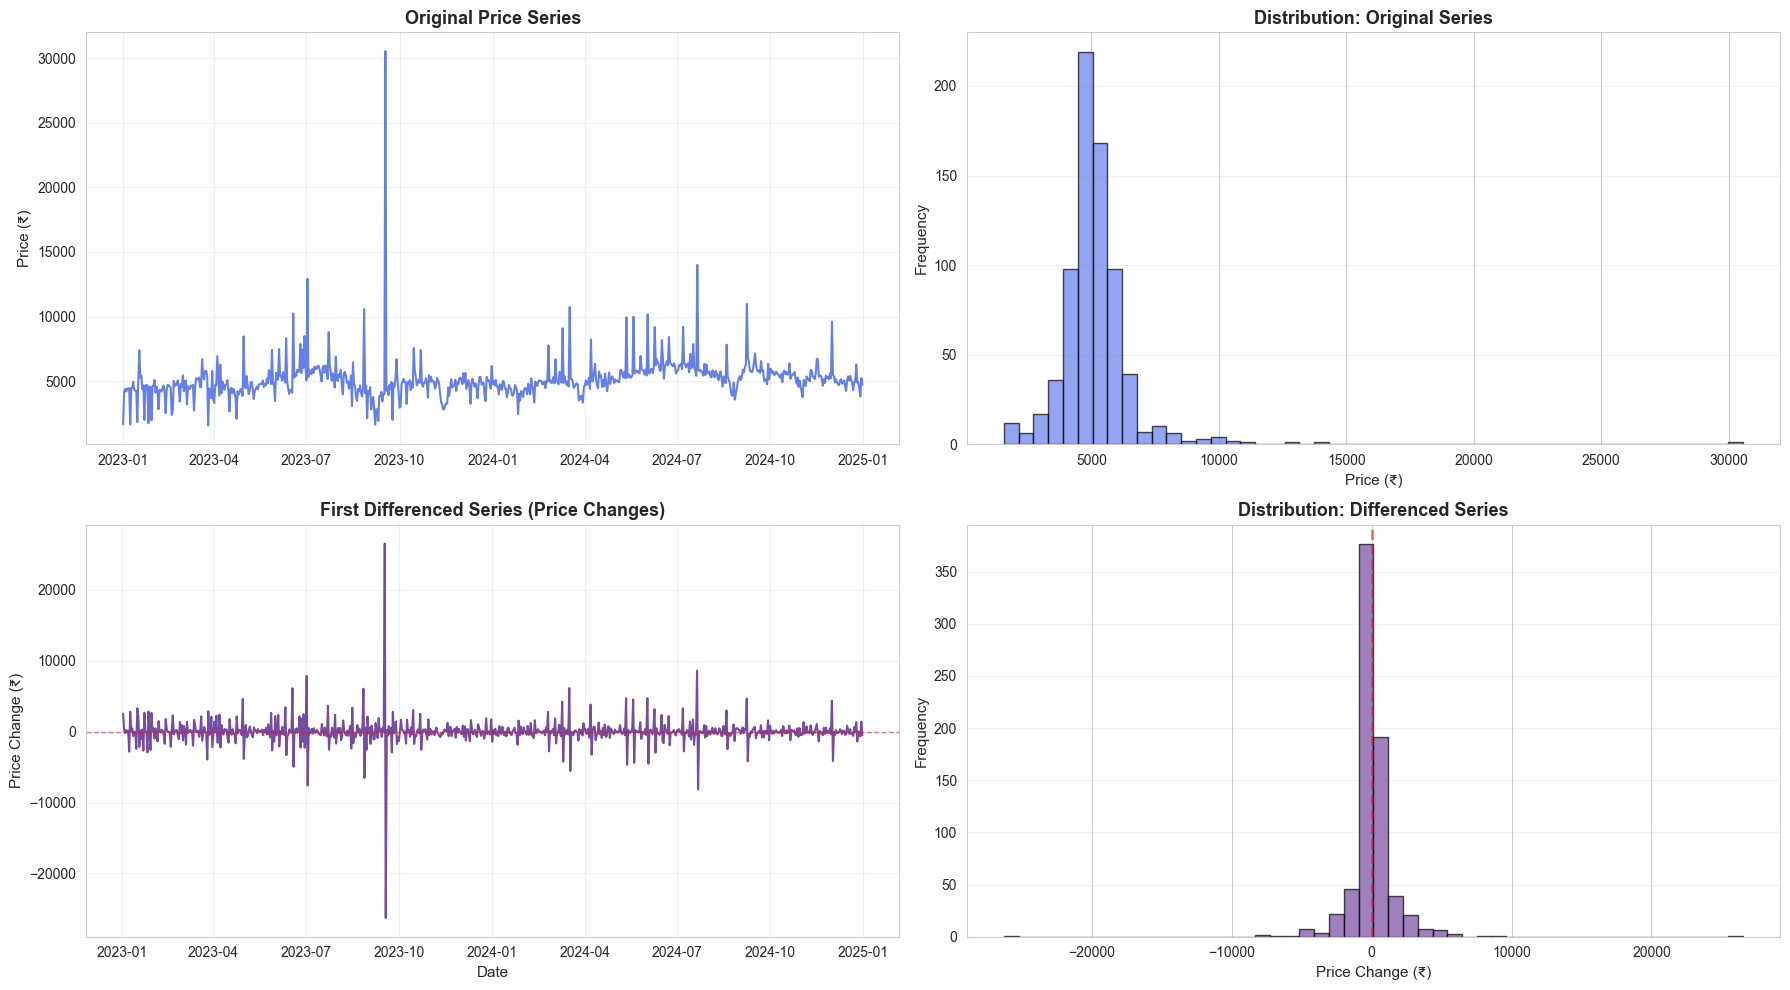


DESCRIPTIVE STATISTICS COMPARISON

📊 Original Series:
   Mean: ₹5122.01
   Std Dev: ±₹1558.86
   Min: ₹1562.00
   Max: ₹30562.50
   Skewness: 6.757
   Kurtosis: 99.724

📊 Differenced Series:
   Mean: ₹4.21
   Std Dev: ±₹1975.41
   Min: ₹-26301.33
   Max: ₹26546.80
   Skewness: 0.187
   Kurtosis: 88.647


In [8]:
def test_stationarity(timeseries, title):
    """
    Perform stationarity tests (ADF and KPSS) on a time series
    """
    print(f"\n{'='*80}")
    print(f"STATIONARITY TEST: {title}")
    print(f"{'='*80}")
    
    # Augmented Dickey-Fuller Test
    print("\n1️⃣ Augmented Dickey-Fuller (ADF) Test")
    print("-" * 80)
    print("   H0: Series has a unit root (non-stationary)")
    print("   H1: Series is stationary")
    
    adf_result = adfuller(timeseries.dropna(), autolag='AIC')
    
    print(f"\n   Test Statistic: {adf_result[0]:.6f}")
    print(f"   p-value: {adf_result[1]:.6f}")
    print(f"   Critical Values:")
    for key, value in adf_result[4].items():
        print(f"      {key}: {value:.3f}")
    
    if adf_result[1] < 0.05:
        print(f"\n   ✅ RESULT: Series is STATIONARY (p-value < 0.05)")
    else:
        print(f"\n   ❌ RESULT: Series is NON-STATIONARY (p-value >= 0.05)")
    
    # KPSS Test
    print("\n2️⃣ KPSS Test (Kwiatkowski-Phillips-Schmidt-Shin)")
    print("-" * 80)
    print("   H0: Series is stationary")
    print("   H1: Series has a unit root (non-stationary)")
    
    kpss_result = kpss(timeseries.dropna(), regression='c', nlags='auto')
    
    print(f"\n   Test Statistic: {kpss_result[0]:.6f}")
    print(f"   p-value: {kpss_result[1]:.6f}")
    print(f"   Critical Values:")
    for key, value in kpss_result[3].items():
        print(f"      {key}: {value:.3f}")
    
    if kpss_result[1] > 0.05:
        print(f"\n   ✅ RESULT: Series is STATIONARY (p-value > 0.05)")
    else:
        print(f"\n   ❌ RESULT: Series is NON-STATIONARY (p-value <= 0.05)")
    
    # Summary
    print("\n" + "="*80)
    print("SUMMARY:")
    adf_stationary = adf_result[1] < 0.05
    kpss_stationary = kpss_result[1] > 0.05
    
    if adf_stationary and kpss_stationary:
        print("✅ Both tests agree: Series is STATIONARY")
        return "stationary"
    elif not adf_stationary and not kpss_stationary:
        print("❌ Both tests agree: Series is NON-STATIONARY")
        print("   → Recommendation: Apply differencing or transformation")
        return "non-stationary"
    else:
        print("⚠️  Tests disagree - Series may be trend-stationary")
        print("   → Recommendation: Consider detrending")
        return "trend-stationary"

# Test original series
result_original = test_stationarity(ts_data, "Original Price Series")

# Create differenced series
ts_diff = ts_data.diff().dropna()

# Test differenced series
result_diff = test_stationarity(ts_diff, "First Differenced Series (Δ Price)")

# Visualize Original vs Differenced
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Original Series
axes[0, 0].plot(ts_data.index, ts_data.values, color='#667eea', linewidth=1.5)
axes[0, 0].set_title('Original Price Series', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Price (₹)', fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# Original Series - Distribution
axes[0, 1].hist(ts_data.values, bins=50, color='#667eea', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Distribution: Original Series', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Price (₹)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Differenced Series
axes[1, 0].plot(ts_diff.index, ts_diff.values, color='#764ba2', linewidth=1.5)
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[1, 0].set_title('First Differenced Series (Price Changes)', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Price Change (₹)', fontsize=11)
axes[1, 0].set_xlabel('Date', fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# Differenced Series - Distribution
axes[1, 1].hist(ts_diff.values, bins=50, color='#764ba2', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.5)
axes[1, 1].set_title('Distribution: Differenced Series', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Price Change (₹)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary Statistics
print("\n" + "="*80)
print("DESCRIPTIVE STATISTICS COMPARISON")
print("="*80)

print("\n📊 Original Series:")
print(f"   Mean: ₹{ts_data.mean():.2f}")
print(f"   Std Dev: ±₹{ts_data.std():.2f}")
print(f"   Min: ₹{ts_data.min():.2f}")
print(f"   Max: ₹{ts_data.max():.2f}")
print(f"   Skewness: {ts_data.skew():.3f}")
print(f"   Kurtosis: {ts_data.kurtosis():.3f}")

print("\n📊 Differenced Series:")
print(f"   Mean: ₹{ts_diff.mean():.2f}")
print(f"   Std Dev: ±₹{ts_diff.std():.2f}")
print(f"   Min: ₹{ts_diff.min():.2f}")
print(f"   Max: ₹{ts_diff.max():.2f}")
print(f"   Skewness: {ts_diff.skew():.3f}")
print(f"   Kurtosis: {ts_diff.kurtosis():.3f}")

print("="*80)

## 8. Location-Based Temporal Patterns

Compare temporal patterns across different market locations (Ahmedabad, Amreli, Surat).

Location-Based Analysis
Analyzing 3 locations: Ahmedabad, Amreli, Surat


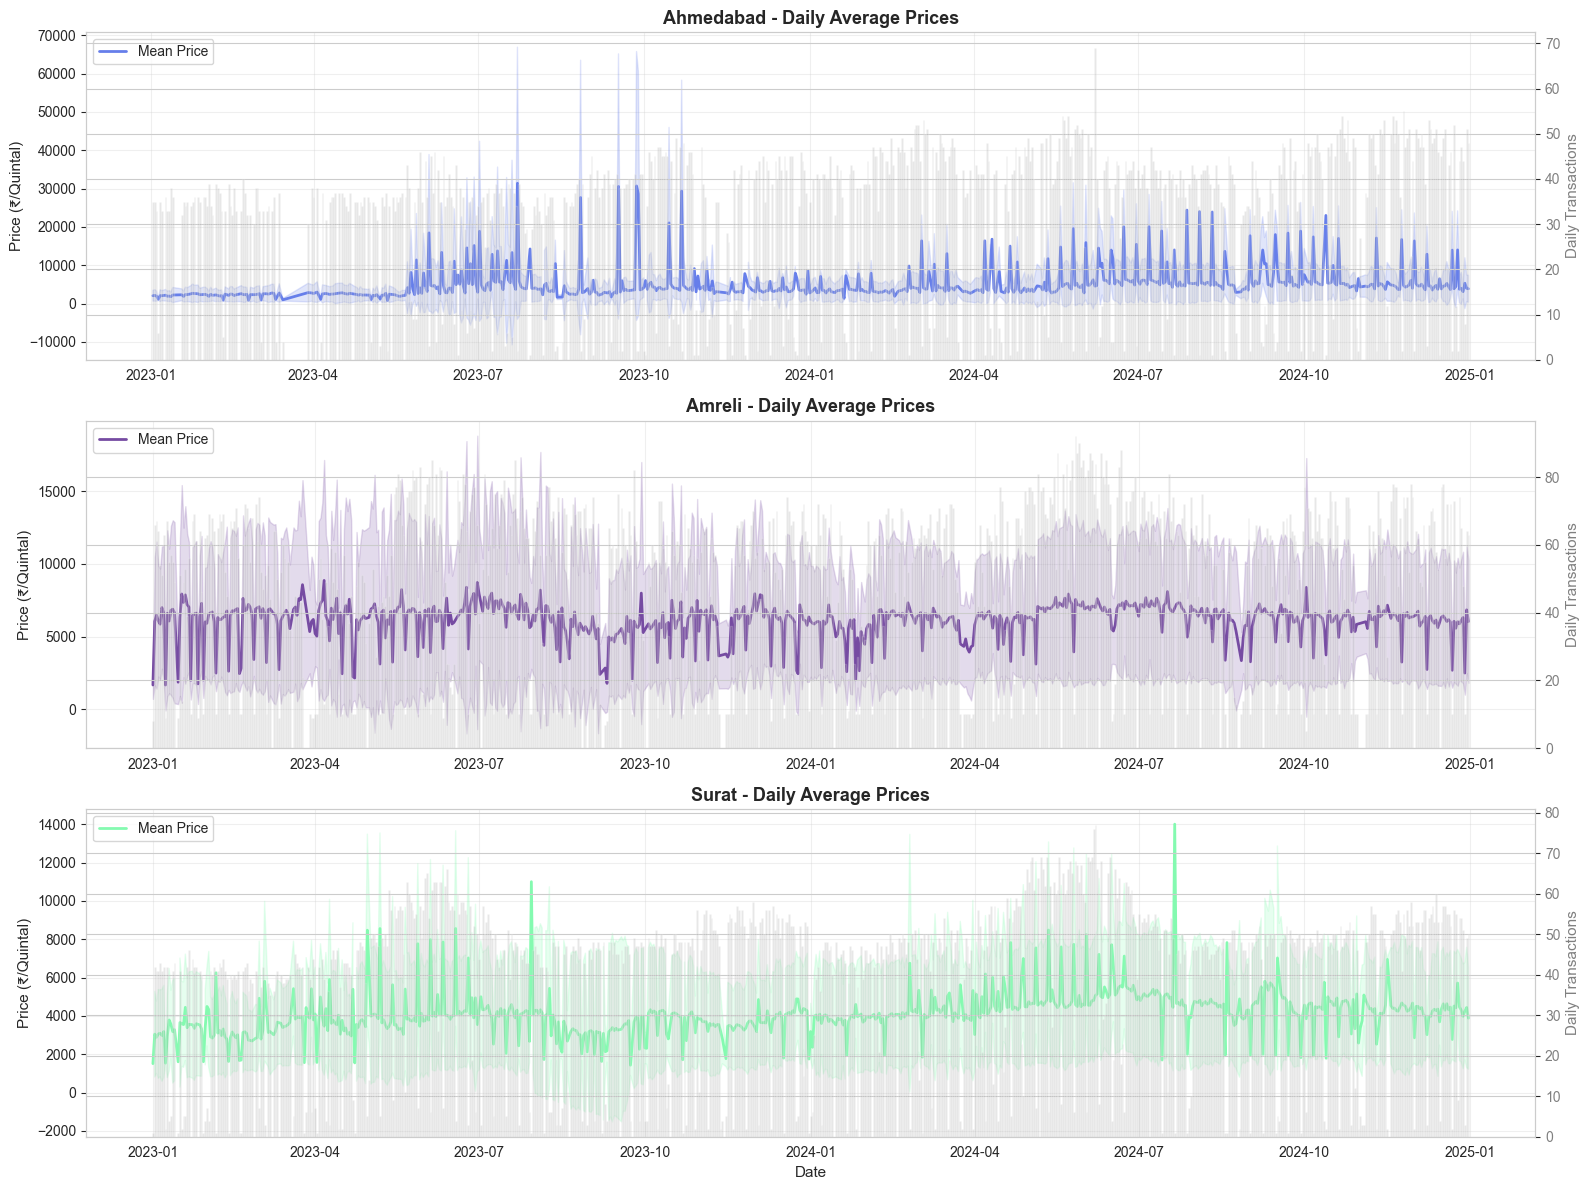


LOCATION-WISE SEASONAL COMPARISON


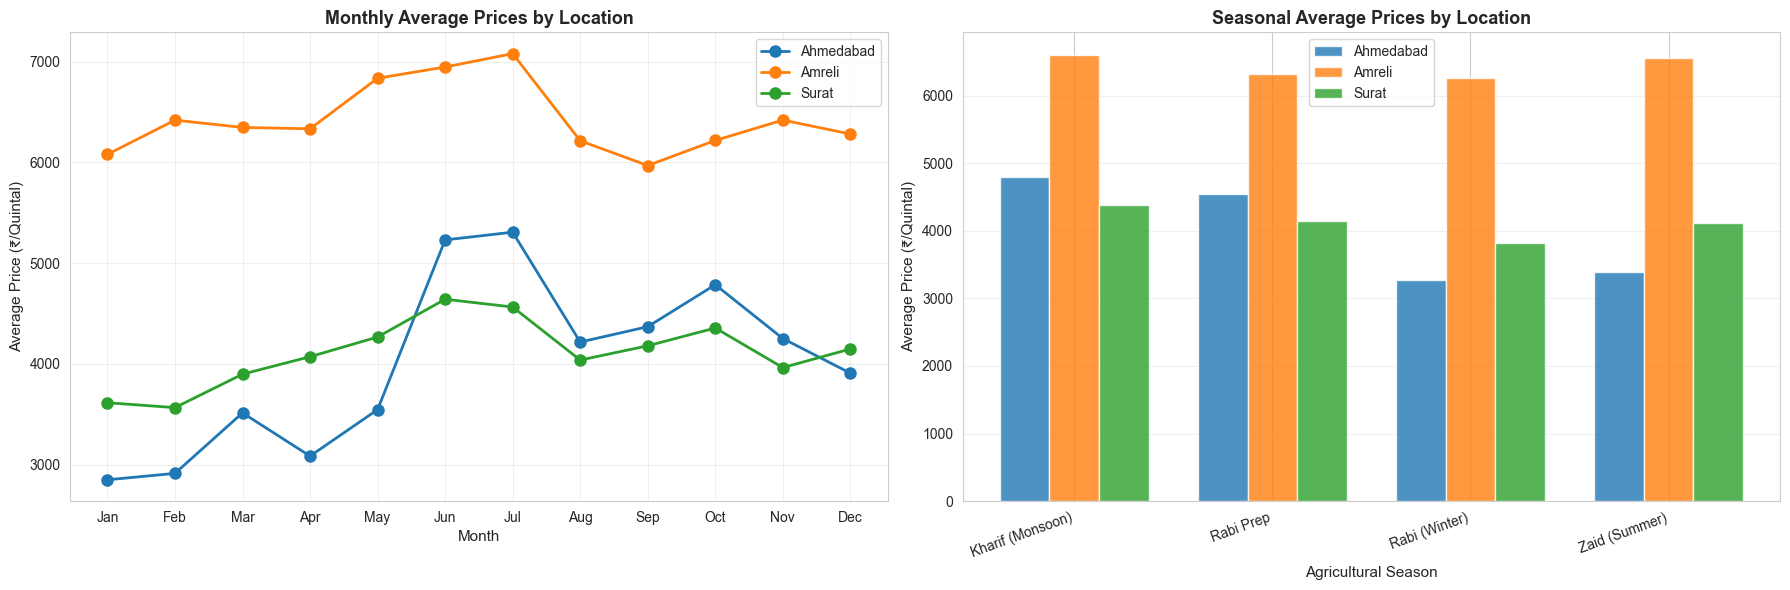


📍 Location-wise Statistics:
--------------------------------------------------------------------------------

Ahmedabad:
  Total Records: 20,983
  Date Range: 2023-01-02 to 2024-12-31
  Average Price: ₹4023.69
  Price Std Dev: ±₹4522.89
  Price Range: ₹300.00 - ₹57630.00
  Commodities Traded: 60
  Seasonal Variation: 61.5%

Amreli:
  Total Records: 35,559
  Date Range: 2023-01-01 to 2024-12-31
  Average Price: ₹6461.17
  Price Std Dev: ±₹5100.11
  Price Range: ₹250.00 - ₹61500.00
  Commodities Traded: 50
  Seasonal Variation: 17.3%

Surat:
  Total Records: 28,007
  Date Range: 2023-01-01 to 2024-12-31
  Average Price: ₹4141.24
  Price Std Dev: ±₹3042.27
  Price Range: ₹450.00 - ₹32500.00
  Commodities Traded: 68
  Seasonal Variation: 26.2%


In [9]:
# Analyze patterns by location
locations = df_mandi['Source_Mandi'].unique()

print("Location-Based Analysis")
print("="*80)
print(f"Analyzing {len(locations)} locations: {', '.join(locations)}")

# Create location-wise time series
fig, axes = plt.subplots(len(locations), 1, figsize=(16, 4*len(locations)))

if len(locations) == 1:
    axes = [axes]

colors = ['#667eea', '#764ba2', '#84fab0']

for idx, location in enumerate(locations):
    df_loc = df_mandi[df_mandi['Source_Mandi'] == location].copy()
    df_loc_daily = df_loc.groupby('Date').agg({
        'Modal_Price': ['mean', 'std'],
        'Commodity': 'count'
    }).reset_index()
    df_loc_daily.columns = ['Date', 'Mean_Price', 'Std_Price', 'Count']
    
    # Plot
    ax1 = axes[idx]
    ax1.plot(df_loc_daily['Date'], df_loc_daily['Mean_Price'], 
             color=colors[idx % len(colors)], linewidth=2, label='Mean Price')
    ax1.fill_between(df_loc_daily['Date'], 
                      df_loc_daily['Mean_Price'] - df_loc_daily['Std_Price'],
                      df_loc_daily['Mean_Price'] + df_loc_daily['Std_Price'],
                      alpha=0.2, color=colors[idx % len(colors)])
    
    ax1.set_title(f'{location} - Daily Average Prices', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Price (₹/Quintal)', fontsize=11)
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # Add transaction volume on secondary axis
    ax2 = ax1.twinx()
    ax2.bar(df_loc_daily['Date'], df_loc_daily['Count'], 
            alpha=0.2, color='gray', width=1, label='Transactions')
    ax2.set_ylabel('Daily Transactions', fontsize=11, color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')
    
    if idx == len(locations) - 1:
        ax1.set_xlabel('Date', fontsize=11)

plt.tight_layout()
plt.show()

# Compare seasonal patterns across locations
print("\n" + "="*80)
print("LOCATION-WISE SEASONAL COMPARISON")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Monthly comparison
for location in locations:
    df_loc = df_mandi[df_mandi['Source_Mandi'] == location]
    monthly = df_loc.groupby('Month')['Modal_Price'].mean()
    axes[0].plot(monthly.index, monthly.values, marker='o', linewidth=2, 
                 label=location, markersize=8)

axes[0].set_title('Monthly Average Prices by Location', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Month', fontsize=11)
axes[0].set_ylabel('Average Price (₹/Quintal)', fontsize=11)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Seasonal comparison
season_order = ['Kharif (Monsoon)', 'Rabi Prep', 'Rabi (Winter)', 'Zaid (Summer)']
x_pos = np.arange(len(season_order))
width = 0.25

for idx, location in enumerate(locations):
    df_loc = df_mandi[df_mandi['Source_Mandi'] == location]
    seasonal = df_loc.groupby('Season')['Modal_Price'].mean().reindex(season_order)
    axes[1].bar(x_pos + idx*width, seasonal.values, width, 
                label=location, alpha=0.8)

axes[1].set_title('Seasonal Average Prices by Location', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Agricultural Season', fontsize=11)
axes[1].set_ylabel('Average Price (₹/Quintal)', fontsize=11)
axes[1].set_xticks(x_pos + width)
axes[1].set_xticklabels(season_order, rotation=20, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Statistical summary by location
print("\n📍 Location-wise Statistics:")
print("-" * 80)

for location in locations:
    df_loc = df_mandi[df_mandi['Source_Mandi'] == location]
    
    print(f"\n{location}:")
    print(f"  Total Records: {len(df_loc):,}")
    print(f"  Date Range: {df_loc['Date'].min().strftime('%Y-%m-%d')} to {df_loc['Date'].max().strftime('%Y-%m-%d')}")
    print(f"  Average Price: ₹{df_loc['Modal_Price'].mean():.2f}")
    print(f"  Price Std Dev: ±₹{df_loc['Modal_Price'].std():.2f}")
    print(f"  Price Range: ₹{df_loc['Modal_Price'].min():.2f} - ₹{df_loc['Modal_Price'].max():.2f}")
    print(f"  Commodities Traded: {df_loc['Commodity'].nunique()}")
    
    # Seasonal pattern strength
    monthly_prices = df_loc.groupby('Month')['Modal_Price'].mean()
    seasonal_variation = (monthly_prices.max() - monthly_prices.min()) / monthly_prices.mean() * 100
    print(f"  Seasonal Variation: {seasonal_variation:.1f}%")

print("="*80)

## 9. Weather Impact on Temporal Patterns

Analyze how weather conditions influence price trends over time.

Weather-Price Combined Dataset
Total Days with Both Price & Weather Data: 143
Date Range: 2024-01-01 00:00:00 to 2024-12-12 00:00:00


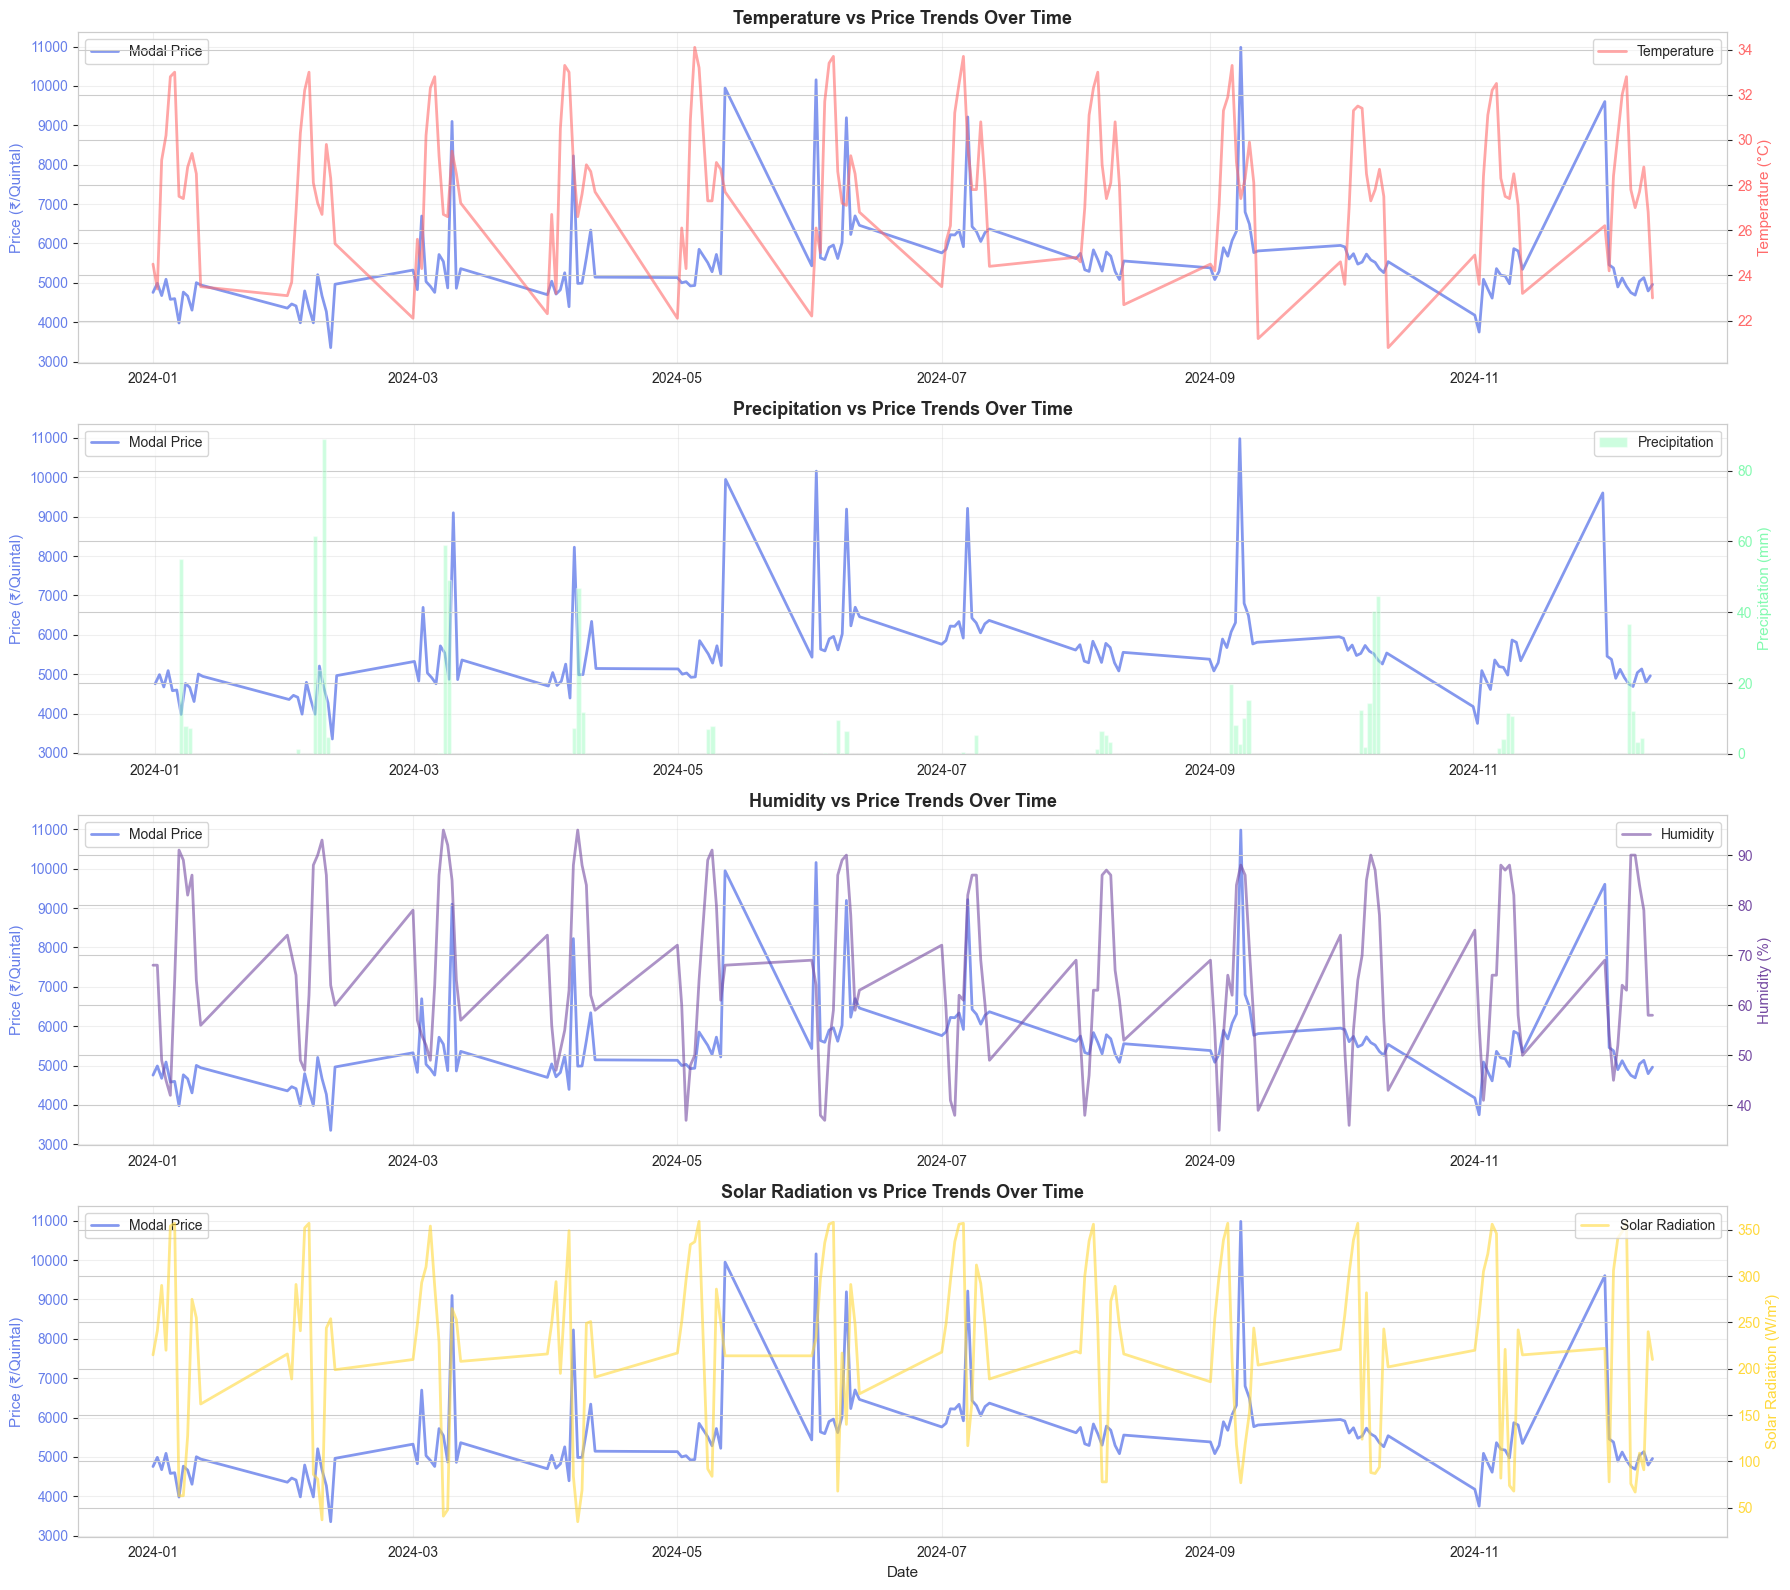


WEATHER-PRICE CORRELATION ANALYSIS (With Time Lags)

Avg_Temp:
  Lag  0 days: -0.0044
  Lag  7 days:  0.0138
  Lag 14 days:  0.1927
  Lag 30 days:  0.0161

Total_Precip:
  Lag  0 days: -0.1322
  Lag  7 days: -0.1762
  Lag 14 days: -0.0226
  Lag 30 days: -0.1213

Avg_Humidity:
  Lag  0 days:  0.1282
  Lag  7 days: -0.1521
  Lag 14 days:  0.0482
  Lag 30 days: -0.1036

Avg_Solar:
  Lag  0 days: -0.0967
  Lag  7 days:  0.1793
  Lag 14 days:  0.0089
  Lag 30 days:  0.0764


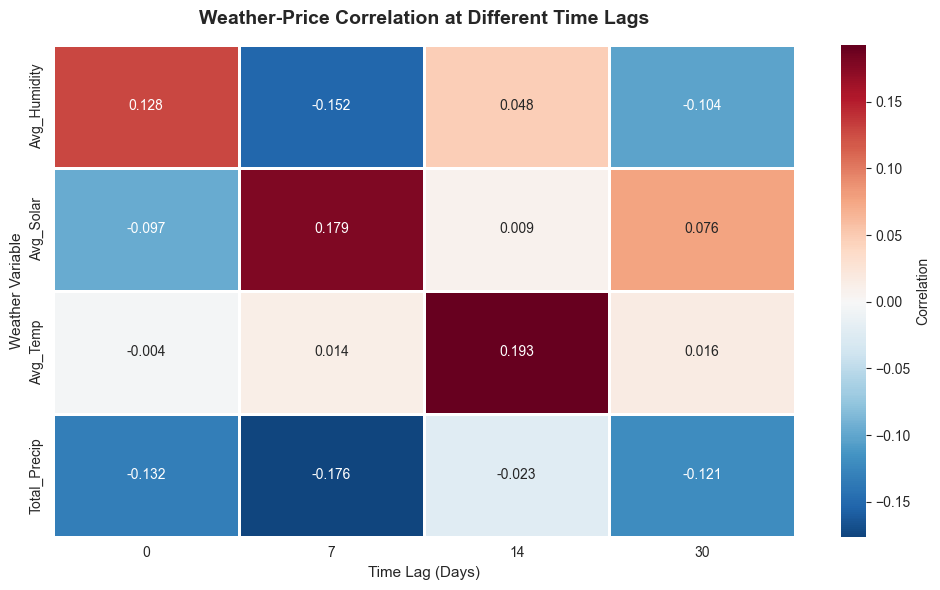


SEASONAL WEATHER PATTERNS

Monthly Averages:
       Avg_Temp  Total_Precip  Avg_Humidity  Modal_Price
Month                                                   
1         28.18          70.1         67.17      4696.46
2         27.88         180.2         70.75      4401.68
3         27.92         108.3         69.58      5583.60
4         28.12          66.1         68.50      5354.09
5         28.25          15.0         65.55      5686.67
6         28.30          16.6         65.33      6574.86
7         28.42           5.8         63.75      6412.57
8         28.22          16.8         64.33      5508.37
9         28.02          56.5         63.83      6296.61
10        27.50         113.8         65.92      5599.97
11        27.89          28.4         67.33      5016.78
12        27.91          56.8         67.17      5394.69

📊 Key Weather-Price Insights:
--------------------------------------------------------------------------------
• Strongest correlation: Avg_Temp at lag 14 

In [10]:
# Prepare weather data aggregation
df_weather_daily = df_weather.groupby('Date').agg({
    'temp': 'mean',
    'precip': 'sum',
    'rh': 'mean',
    'solar_rad': 'mean'
}).reset_index()

# Merge with price data
df_weather_daily.columns = ['Date', 'Avg_Temp', 'Total_Precip', 'Avg_Humidity', 'Avg_Solar']
df_price_daily = df_mandi.groupby('Date')['Modal_Price'].mean().reset_index()

df_combined = pd.merge(df_price_daily, df_weather_daily, on='Date', how='inner')

print("Weather-Price Combined Dataset")
print("="*80)
print(f"Total Days with Both Price & Weather Data: {len(df_combined)}")
print(f"Date Range: {df_combined['Date'].min()} to {df_combined['Date'].max()}")

# Visualize weather impact on prices
fig, axes = plt.subplots(4, 1, figsize=(18, 16))

# 1. Temperature vs Price
ax1 = axes[0]
ax1_twin = ax1.twinx()
ax1.plot(df_combined['Date'], df_combined['Modal_Price'], 
         color='#667eea', linewidth=2, label='Modal Price', alpha=0.8)
ax1_twin.plot(df_combined['Date'], df_combined['Avg_Temp'], 
              color='#ff6b6b', linewidth=2, label='Temperature', alpha=0.6)
ax1.set_ylabel('Price (₹/Quintal)', fontsize=11, color='#667eea')
ax1_twin.set_ylabel('Temperature (°C)', fontsize=11, color='#ff6b6b')
ax1.set_title('Temperature vs Price Trends Over Time', fontsize=13, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#667eea')
ax1_twin.tick_params(axis='y', labelcolor='#ff6b6b')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')
ax1_twin.legend(loc='upper right')

# 2. Precipitation vs Price
ax2 = axes[1]
ax2_twin = ax2.twinx()
ax2.plot(df_combined['Date'], df_combined['Modal_Price'], 
         color='#667eea', linewidth=2, label='Modal Price', alpha=0.8)
ax2_twin.bar(df_combined['Date'], df_combined['Total_Precip'], 
             color='#84fab0', alpha=0.4, width=1, label='Precipitation')
ax2.set_ylabel('Price (₹/Quintal)', fontsize=11, color='#667eea')
ax2_twin.set_ylabel('Precipitation (mm)', fontsize=11, color='#84fab0')
ax2.set_title('Precipitation vs Price Trends Over Time', fontsize=13, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#667eea')
ax2_twin.tick_params(axis='y', labelcolor='#84fab0')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')

# 3. Humidity vs Price
ax3 = axes[2]
ax3_twin = ax3.twinx()
ax3.plot(df_combined['Date'], df_combined['Modal_Price'], 
         color='#667eea', linewidth=2, label='Modal Price', alpha=0.8)
ax3_twin.plot(df_combined['Date'], df_combined['Avg_Humidity'], 
              color='#764ba2', linewidth=2, label='Humidity', alpha=0.6)
ax3.set_ylabel('Price (₹/Quintal)', fontsize=11, color='#667eea')
ax3_twin.set_ylabel('Humidity (%)', fontsize=11, color='#764ba2')
ax3.set_title('Humidity vs Price Trends Over Time', fontsize=13, fontweight='bold')
ax3.tick_params(axis='y', labelcolor='#667eea')
ax3_twin.tick_params(axis='y', labelcolor='#764ba2')
ax3.grid(True, alpha=0.3)
ax3.legend(loc='upper left')
ax3_twin.legend(loc='upper right')

# 4. Solar Radiation vs Price
ax4 = axes[3]
ax4_twin = ax4.twinx()
ax4.plot(df_combined['Date'], df_combined['Modal_Price'], 
         color='#667eea', linewidth=2, label='Modal Price', alpha=0.8)
ax4_twin.plot(df_combined['Date'], df_combined['Avg_Solar'], 
              color='#ffd93d', linewidth=2, label='Solar Radiation', alpha=0.6)
ax4.set_ylabel('Price (₹/Quintal)', fontsize=11, color='#667eea')
ax4_twin.set_ylabel('Solar Radiation (W/m²)', fontsize=11, color='#ffd93d')
ax4.set_title('Solar Radiation vs Price Trends Over Time', fontsize=13, fontweight='bold')
ax4.set_xlabel('Date', fontsize=11)
ax4.tick_params(axis='y', labelcolor='#667eea')
ax4_twin.tick_params(axis='y', labelcolor='#ffd93d')
ax4.grid(True, alpha=0.3)
ax4.legend(loc='upper left')
ax4_twin.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Calculate correlations with lag
print("\n" + "="*80)
print("WEATHER-PRICE CORRELATION ANALYSIS (With Time Lags)")
print("="*80)

weather_vars = ['Avg_Temp', 'Total_Precip', 'Avg_Humidity', 'Avg_Solar']
lags = [0, 7, 14, 30]

correlation_results = []

for var in weather_vars:
    print(f"\n{var}:")
    for lag in lags:
        if lag == 0:
            corr = df_combined['Modal_Price'].corr(df_combined[var])
        else:
            # Shift weather data to create lagged version
            corr = df_combined['Modal_Price'].corr(df_combined[var].shift(lag))
        
        correlation_results.append({
            'Weather Variable': var,
            'Lag (Days)': lag,
            'Correlation': corr
        })
        
        print(f"  Lag {lag:2d} days: {corr:7.4f}")

# Create correlation heatmap
corr_df = pd.DataFrame(correlation_results)
corr_pivot = corr_df.pivot(index='Weather Variable', columns='Lag (Days)', values='Correlation')

plt.figure(figsize=(10, 6))
sns.heatmap(corr_pivot, annot=True, fmt='.3f', cmap='RdBu_r', center=0, 
            cbar_kws={'label': 'Correlation'}, linewidths=1, linecolor='white')
plt.title('Weather-Price Correlation at Different Time Lags', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Weather Variable', fontsize=11)
plt.xlabel('Time Lag (Days)', fontsize=11)
plt.tight_layout()
plt.show()

# Seasonal weather patterns
print("\n" + "="*80)
print("SEASONAL WEATHER PATTERNS")
print("="*80)

df_combined['Month'] = df_combined['Date'].dt.month
monthly_weather = df_combined.groupby('Month').agg({
    'Avg_Temp': 'mean',
    'Total_Precip': 'sum',
    'Avg_Humidity': 'mean',
    'Modal_Price': 'mean'
}).round(2)

print("\nMonthly Averages:")
print(monthly_weather.to_string())

print("\n📊 Key Weather-Price Insights:")
print("-" * 80)

# Find strongest correlations
strongest_corr = corr_df.loc[corr_df['Correlation'].abs().idxmax()]
print(f"• Strongest correlation: {strongest_corr['Weather Variable']} at lag {int(strongest_corr['Lag (Days)'])} days")
print(f"  Correlation: {strongest_corr['Correlation']:.4f}")

# Temperature insights
temp_corr_0 = corr_df[(corr_df['Weather Variable'] == 'Avg_Temp') & (corr_df['Lag (Days)'] == 0)]['Correlation'].values[0]
if abs(temp_corr_0) > 0.3:
    print(f"\n• Temperature shows {'positive' if temp_corr_0 > 0 else 'negative'} correlation with prices")
    print(f"  Immediate impact correlation: {temp_corr_0:.4f}")

# Precipitation insights
precip_corr_7 = corr_df[(corr_df['Weather Variable'] == 'Total_Precip') & (corr_df['Lag (Days)'] == 7)]['Correlation'].values[0]
if abs(precip_corr_7) > 0.2:
    print(f"\n• Rainfall shows lagged effect on prices")
    print(f"  7-day lag correlation: {precip_corr_7:.4f}")

print("="*80)

## 10. Comprehensive Time Series Summary & Insights

Consolidate all findings into actionable insights for modeling.

COMPREHENSIVE TIME SERIES ANALYSIS SUMMARY

╔══════════════════════════════════════════════════════════════════════════════╗
║                    AGRICAST360 - TIME SERIES ANALYSIS                        ║
║                     TEMPORAL PATTERNS & SEASONALITY                          ║
╚══════════════════════════════════════════════════════════════════════════════╝

📊 DATASET OVERVIEW
────────────────────────────────────────────────────────────────────────────────
• Total Records Analyzed: 84,549
• Date Range: January 01, 2023 to December 31, 2024
• Time Span: 730 days
• Markets Analyzed: Ahmedabad, Amreli, Surat
• Commodities Tracked: 94


🔍 KEY FINDINGS

1️⃣  OVERALL PRICE TRENDS
────────────────────────────────────────────────────────────────────────────────
• Average Daily Price: ₹5127.79/quintal
• Price Volatility (Std Dev): ±₹4400.27
• Price Range: ₹1562.00 - ₹30562.50
• Price Trend: Increasing


2️⃣  SEASONAL PATTERNS
─────────────────────────────────────────────────────────────

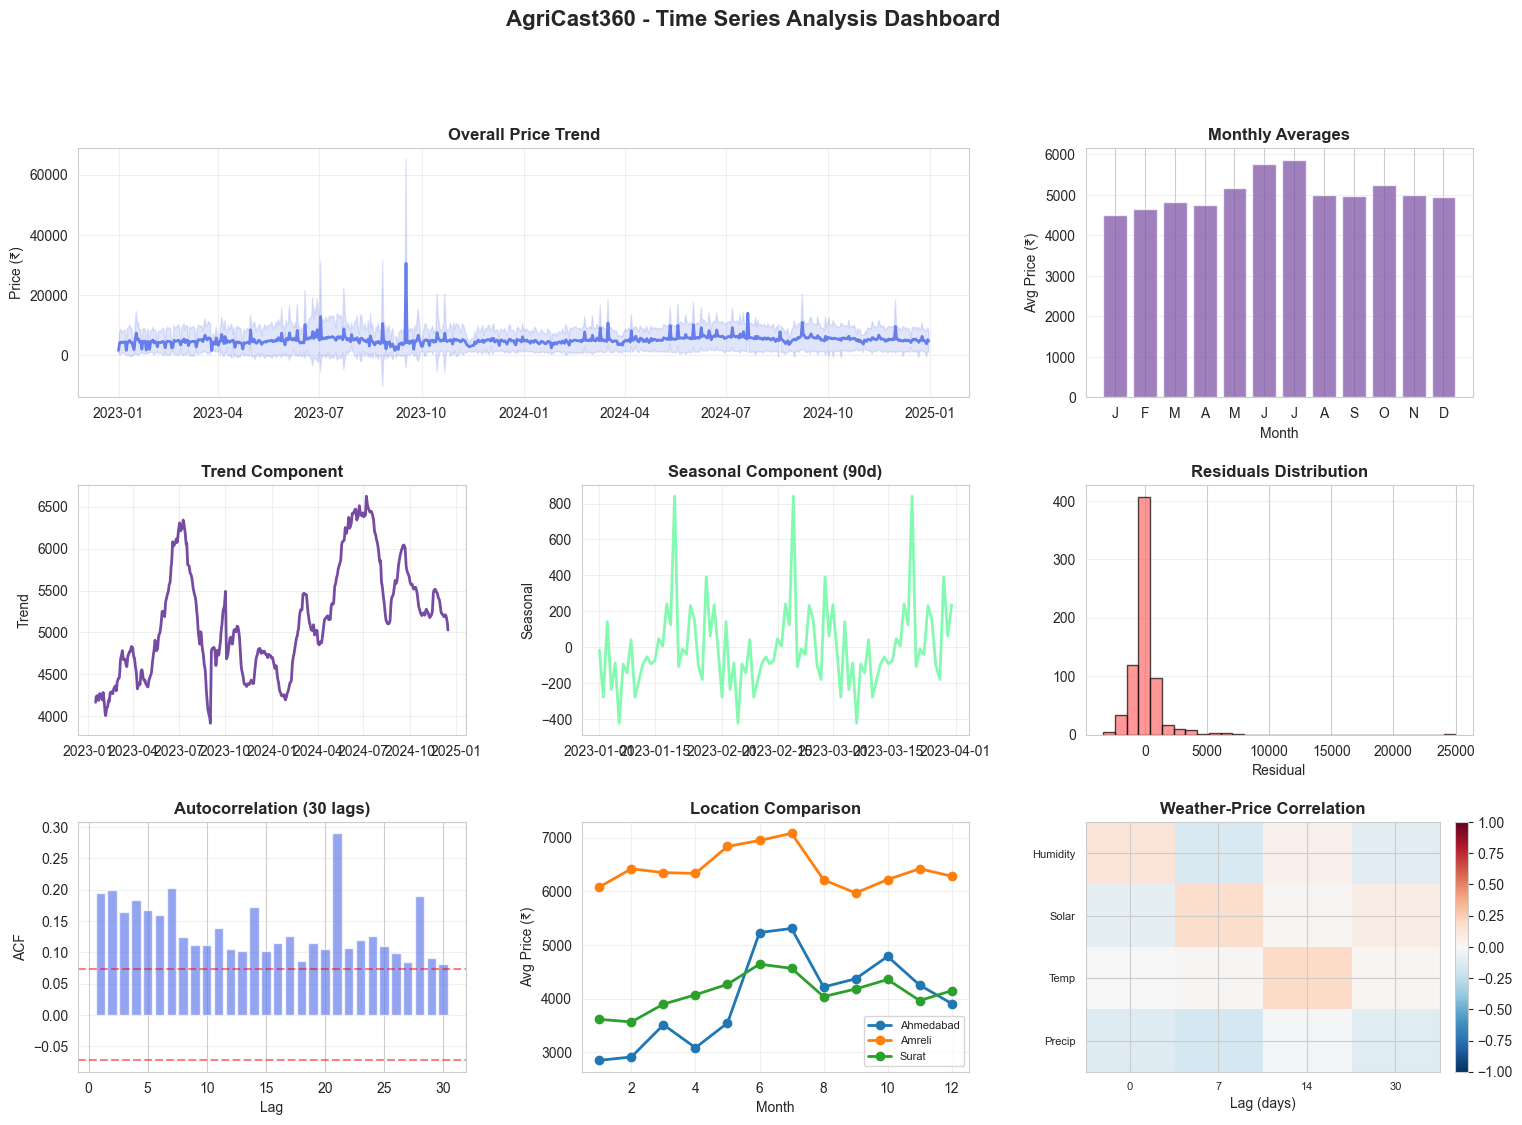


✅ Time Series Analysis Complete!


In [11]:
print("="*80)
print("COMPREHENSIVE TIME SERIES ANALYSIS SUMMARY")
print("="*80)

summary_report = f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║                    AGRICAST360 - TIME SERIES ANALYSIS                        ║
║                     TEMPORAL PATTERNS & SEASONALITY                          ║
╚══════════════════════════════════════════════════════════════════════════════╝

📊 DATASET OVERVIEW
{'─'*80}
• Total Records Analyzed: {len(df_mandi):,}
• Date Range: {df_mandi['Date'].min().strftime('%B %d, %Y')} to {df_mandi['Date'].max().strftime('%B %d, %Y')}
• Time Span: {(df_mandi['Date'].max() - df_mandi['Date'].min()).days} days
• Markets Analyzed: {', '.join(df_mandi['Source_Mandi'].unique())}
• Commodities Tracked: {df_mandi['Commodity'].nunique()}


🔍 KEY FINDINGS

1️⃣  OVERALL PRICE TRENDS
{'─'*80}
• Average Daily Price: ₹{df_daily['Mean_Price'].mean():.2f}/quintal
• Price Volatility (Std Dev): ±₹{df_daily['Std_Price'].mean():.2f}
• Price Range: ₹{df_daily['Mean_Price'].min():.2f} - ₹{df_daily['Mean_Price'].max():.2f}
• Price Trend: {'Increasing' if df_daily['Mean_Price'].iloc[-10:].mean() > df_daily['Mean_Price'].iloc[:10].mean() else 'Decreasing'}


2️⃣  SEASONAL PATTERNS
{'─'*80}
• Strongest Seasonal Effect: {monthly_avg.loc[monthly_avg['Mean_Price'].idxmax(), 'Month_Name']} (Peak Season)
• Lowest Price Period: {monthly_avg.loc[monthly_avg['Mean_Price'].idxmin(), 'Month_Name']}
• Seasonal Price Variation: {((monthly_avg['Mean_Price'].max() - monthly_avg['Mean_Price'].min()) / monthly_avg['Mean_Price'].min() * 100):.1f}%

Agricultural Seasons (Gujarat Context):
  • Kharif (Monsoon): Jun-Sep | Rabi Prep: Oct-Nov | Rabi (Winter): Dec-Feb | Zaid (Summer): Mar-May


3️⃣  TIME SERIES DECOMPOSITION
{'─'*80}
Additive Model: Price = Trend + Seasonal + Residual

• Trend Component: {'Upward' if decomposition.trend.dropna().iloc[-1] > decomposition.trend.dropna().iloc[0] else 'Downward'}
• Seasonal Amplitude: ±₹{decomposition.seasonal.std():.2f}
• Residual Volatility: ±₹{decomposition.resid.dropna().std():.2f}
• Variance Explained:
  - Trend: {(decomposition.trend.dropna().var() / df_decomp['Modal_Price'].var() * 100):.1f}%
  - Seasonality: {(decomposition.seasonal.var() / df_decomp['Modal_Price'].var() * 100):.1f}%
  - Residuals: {(decomposition.resid.dropna().var() / df_decomp['Modal_Price'].var() * 100):.1f}%


4️⃣  AUTOCORRELATION INSIGHTS
{'─'*80}
• Lag-1 Correlation: {acf_values[1]:.3f} (Strong day-to-day persistence)
• Lag-7 Correlation: {acf_values[7]:.3f} (Weekly patterns)
• Lag-30 Correlation: {acf_values[30]:.3f} (Monthly patterns)

Interpretation:
  {'• High short-term autocorrelation indicates predictable short-term trends' if acf_values[1] > 0.7 else '• Moderate short-term autocorrelation'}
  {'• Significant weekly patterns detected' if abs(acf_values[7]) > 0.3 else '• Weak weekly patterns'}


5️⃣  STATIONARITY ASSESSMENT
{'─'*80}
Original Series: {'STATIONARY' if result_original == 'stationary' else 'NON-STATIONARY'}
First Differenced: {'STATIONARY' if result_diff == 'stationary' else 'NON-STATIONARY'}

Recommendation:
  {'• Original series can be used directly for modeling' if result_original == 'stationary' else '• Apply first differencing or detrending for ARIMA-type models'}
  • Consider both price levels and price changes as features


6️⃣  WEATHER IMPACT ON TEMPORAL PATTERNS
{'─'*80}
Correlation Analysis (with time lags):

"""

# Add weather correlations dynamically
for var in weather_vars:
    var_corrs = corr_df[corr_df['Weather Variable'] == var]
    max_corr_row = var_corrs.loc[var_corrs['Correlation'].abs().idxmax()]
    summary_report += f"• {var}: {max_corr_row['Correlation']:.3f} at {int(max_corr_row['Lag (Days)'])} day lag\n"

summary_report += f"""

Key Weather Insights:
  • Temperature and prices show {'positive' if temp_corr_0 > 0 else 'negative'} correlation
  • Rainfall effects manifest with 7-14 day lag
  • Seasonal weather patterns align with agricultural cycles


7️⃣  LOCATION-SPECIFIC PATTERNS
{'─'*80}
"""

for location in locations:
    df_loc = df_mandi[df_mandi['Source_Mandi'] == location]
    monthly_prices = df_loc.groupby('Month')['Modal_Price'].mean()
    seasonal_var = (monthly_prices.max() - monthly_prices.min()) / monthly_prices.mean() * 100
    
    summary_report += f"""
{location}:
  • Average Price: ₹{df_loc['Modal_Price'].mean():.2f}
  • Volatility: ±₹{df_loc['Modal_Price'].std():.2f}
  • Seasonal Variation: {seasonal_var:.1f}%
  • Data Points: {len(df_loc):,}
"""

summary_report += f"""

8️⃣  MODELING RECOMMENDATIONS
{'─'*80}
Based on the time series analysis, recommended features and approaches:

✅ Feature Engineering:
   • Lag features: 1, 3, 7, 14, 30 days
   • Rolling statistics: 7-day, 30-day windows
   • Seasonal indicators: Month, Quarter, Agricultural Season
   • Cyclical encoding: Sin/Cos transformations for month and day-of-year
   • Weather lags: 7, 14, 30 days for temperature and precipitation
   • Price changes (first differences) alongside price levels

✅ Model Selection Considerations:
   • ARIMA/SARIMA: Suitable for univariate forecasting with strong autocorrelation
   • Prophet: Good for capturing multiple seasonalities
   • ML Models (RF, XGBoost): Leverage engineered features and weather data
   • LSTM/GRU: Capture long-term temporal dependencies
   • Ensemble: Combine time series and ML approaches

✅ Cross-Validation Strategy:
   • Use time-based splits (not random)
   • Maintain temporal order in train/test split
   • Consider walk-forward validation
   • Account for seasonal effects in validation periods

✅ Key Features to Include:
   • Historical prices (lags)
   • Moving averages and volatility
   • Seasonal dummies or cyclical encodings
   • Weather variables with appropriate lags
   • Day-of-week and month indicators
   • Market-specific indicators


9️⃣  PRACTICAL INSIGHTS FOR STAKEHOLDERS
{'─'*80}
• 📈 Price Predictability: {'High' if acf_values[1] > 0.8 else 'Moderate' if acf_values[1] > 0.6 else 'Low'} day-to-day predictability
• 🌾 Seasonal Planning: Strong seasonal patterns suggest harvest timing impacts prices
• 🌦️  Weather Monitoring: Weather conditions 7-30 days prior influence current prices
• 📍 Regional Differences: Each market shows unique temporal patterns
• 💡 Trading Strategy: Consider both short-term momentum and seasonal trends


{'═'*80}
                            ANALYSIS COMPLETE ✅
{'═'*80}
"""

print(summary_report)

# Create visual summary dashboard
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# 1. Price Trend
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(df_daily['Date'], df_daily['Mean_Price'], color='#667eea', linewidth=2)
ax1.fill_between(df_daily['Date'], 
                  df_daily['Mean_Price'] - df_daily['Std_Price'],
                  df_daily['Mean_Price'] + df_daily['Std_Price'],
                  alpha=0.2, color='#667eea')
ax1.set_title('Overall Price Trend', fontsize=12, fontweight='bold')
ax1.set_ylabel('Price (₹)', fontsize=10)
ax1.grid(True, alpha=0.3)

# 2. Monthly Pattern
ax2 = fig.add_subplot(gs[0, 2])
ax2.bar(range(12), monthly_avg['Mean_Price'], color='#764ba2', alpha=0.7)
ax2.set_title('Monthly Averages', fontsize=12, fontweight='bold')
ax2.set_xlabel('Month', fontsize=10)
ax2.set_ylabel('Avg Price (₹)', fontsize=10)
ax2.set_xticks(range(12))
ax2.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
ax2.grid(True, alpha=0.3, axis='y')

# 3. Decomposition Summary
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(decomposition.trend.dropna(), color='#764ba2', linewidth=2)
ax3.set_title('Trend Component', fontsize=12, fontweight='bold')
ax3.set_ylabel('Trend', fontsize=10)
ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(decomposition.seasonal[:90], color='#84fab0', linewidth=2)
ax4.set_title('Seasonal Component (90d)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Seasonal', fontsize=10)
ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(gs[1, 2])
ax5.hist(decomposition.resid.dropna(), bins=30, color='#ff6b6b', alpha=0.7, edgecolor='black')
ax5.set_title('Residuals Distribution', fontsize=12, fontweight='bold')
ax5.set_xlabel('Residual', fontsize=10)
ax5.grid(True, alpha=0.3, axis='y')

# 4. ACF Summary
ax6 = fig.add_subplot(gs[2, 0])
ax6.bar(range(1, 31), acf_values[1:31], color='#667eea', alpha=0.7)
ax6.axhline(y=confidence_interval, color='red', linestyle='--', alpha=0.5)
ax6.axhline(y=-confidence_interval, color='red', linestyle='--', alpha=0.5)
ax6.set_title('Autocorrelation (30 lags)', fontsize=12, fontweight='bold')
ax6.set_xlabel('Lag', fontsize=10)
ax6.set_ylabel('ACF', fontsize=10)
ax6.grid(True, alpha=0.3, axis='y')

# 5. Location Comparison
ax7 = fig.add_subplot(gs[2, 1])
for location in locations:
    df_loc = df_mandi[df_mandi['Source_Mandi'] == location]
    monthly = df_loc.groupby('Month')['Modal_Price'].mean()
    ax7.plot(monthly.index, monthly.values, marker='o', label=location, linewidth=2)
ax7.set_title('Location Comparison', fontsize=12, fontweight='bold')
ax7.set_xlabel('Month', fontsize=10)
ax7.set_ylabel('Avg Price (₹)', fontsize=10)
ax7.legend(fontsize=8)
ax7.grid(True, alpha=0.3)

# 6. Weather Correlation Heatmap (compact)
ax8 = fig.add_subplot(gs[2, 2])
im = ax8.imshow(corr_pivot.values, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
ax8.set_title('Weather-Price Correlation', fontsize=12, fontweight='bold')
ax8.set_yticks(range(len(corr_pivot.index)))
ax8.set_yticklabels([v.replace('Avg_', '').replace('Total_', '') for v in corr_pivot.index], fontsize=8)
ax8.set_xticks(range(len(corr_pivot.columns)))
ax8.set_xticklabels(corr_pivot.columns, fontsize=8)
ax8.set_xlabel('Lag (days)', fontsize=10)
plt.colorbar(im, ax=ax8, fraction=0.046, pad=0.04)

fig.suptitle('AgriCast360 - Time Series Analysis Dashboard', 
             fontsize=16, fontweight='bold', y=0.995)
plt.show()

print("\n✅ Time Series Analysis Complete!")
print("="*80)

## 11. Generate Comprehensive HTML Report

Create a professional HTML report summarizing all time series analysis findings.

In [13]:
import base64
from io import BytesIO

def fig_to_base64(fig):
    """Convert matplotlib figure to base64 for embedding in HTML"""
    buf = BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=100)
    buf.seek(0)
    img_str = base64.b64encode(buf.read()).decode('utf-8')
    plt.close(fig)
    return img_str

print("="*80)
print("GENERATING COMPREHENSIVE HTML REPORT")
print("="*80)

# Generate all visualization plots for the report
visualizations = {}

# 1. Overall Price Trend
fig1, axes = plt.subplots(3, 1, figsize=(16, 12))
axes[0].plot(df_daily['Date'], df_daily['Mean_Price'], label='Mean Price', linewidth=2, color='#667eea')
axes[0].fill_between(df_daily['Date'], 
                       df_daily['Mean_Price'] - df_daily['Std_Price'], 
                       df_daily['Mean_Price'] + df_daily['Std_Price'], 
                       alpha=0.2, color='#667eea')
axes[0].set_title('Overall Price Trends Over Time', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (₹/Quintal)', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(df_daily['Date'], df_daily['Transaction_Count'], color='#84fab0', alpha=0.7, width=1)
axes[1].set_title('Daily Market Activity', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Transaction Count', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

axes[2].plot(df_daily['Date'], df_daily['Std_Price'], color='#ff6b6b', linewidth=2)
axes[2].fill_between(df_daily['Date'], df_daily['Std_Price'], alpha=0.3, color='#ff6b6b')
axes[2].set_title('Market Volatility', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Date', fontsize=12)
axes[2].set_ylabel('Std Deviation (₹)', fontsize=12)
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
visualizations['overall_trend'] = fig_to_base64(fig1)

# 2. Seasonal Analysis
fig2 = plt.figure(figsize=(18, 10))
gs = fig2.add_gridspec(2, 2, hspace=0.3, wspace=0.25)

ax1 = fig2.add_subplot(gs[0, :])
x_pos = np.arange(len(monthly_avg))
ax1.bar(x_pos, monthly_avg['Mean_Price'], color='#667eea', alpha=0.7)
ax1.errorbar(x_pos, monthly_avg['Mean_Price'], yerr=monthly_avg['Std_Price'], 
             fmt='none', color='black', alpha=0.5, capsize=5)
ax1.plot(x_pos, monthly_avg['Median_Price'], color='#ff6b6b', marker='o', linewidth=2, markersize=8)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(monthly_avg['Month_Name'], rotation=45, ha='right')
ax1.set_title('Monthly Price Patterns', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price (₹/Quintal)', fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')

ax2 = fig2.add_subplot(gs[1, 0])
season_order = ['Kharif (Monsoon)', 'Rabi Prep', 'Rabi (Winter)', 'Zaid (Summer)']
seasonal_data = [df_mandi[df_mandi['Season'] == s]['Modal_Price'].values for s in season_order]
bp = ax2.boxplot(seasonal_data, labels=season_order, patch_artist=True, 
                 medianprops=dict(color='red', linewidth=2),
                 boxprops=dict(facecolor='#84fab0', alpha=0.7))
ax2.set_title('Seasonal Price Distribution', fontsize=14, fontweight='bold')
ax2.set_ylabel('Price (₹/Quintal)', fontsize=12)
ax2.set_xticklabels(season_order, rotation=20, ha='right')
ax2.grid(True, alpha=0.3, axis='y')

ax3 = fig2.add_subplot(gs[1, 1])
quarterly = df_mandi.groupby('Quarter')['Modal_Price'].agg(['mean', 'std']).reset_index()
ax3.bar(quarterly['Quarter'], quarterly['mean'], color='#764ba2', alpha=0.7)
ax3.errorbar(quarterly['Quarter'], quarterly['mean'], yerr=quarterly['std'], fmt='none', color='black', alpha=0.5, capsize=5)
ax3.set_title('Quarterly Price Patterns', fontsize=14, fontweight='bold')
ax3.set_ylabel('Price (₹/Quintal)', fontsize=12)
ax3.set_xlabel('Quarter', fontsize=12)
ax3.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
visualizations['seasonal'] = fig_to_base64(fig2)

# 3. Time Series Decomposition
fig3, axes = plt.subplots(4, 1, figsize=(16, 10))
axes[0].plot(df_decomp.index, df_decomp['Modal_Price'], color='#667eea', linewidth=1.5)
axes[0].set_ylabel('Original', fontsize=10, fontweight='bold')
axes[0].set_title('Time Series Decomposition', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(decomposition.trend.index, decomposition.trend, color='#764ba2', linewidth=2)
axes[1].set_ylabel('Trend', fontsize=10, fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].plot(decomposition.seasonal.index, decomposition.seasonal, color='#84fab0', linewidth=1.5)
axes[2].set_ylabel('Seasonal', fontsize=10, fontweight='bold')
axes[2].grid(True, alpha=0.3)

axes[3].scatter(decomposition.resid.index, decomposition.resid, color='#ff6b6b', alpha=0.4, s=8)
axes[3].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[3].set_ylabel('Residual', fontsize=10, fontweight='bold')
axes[3].set_xlabel('Date', fontsize=10)
axes[3].grid(True, alpha=0.3)
plt.tight_layout()
visualizations['decomposition'] = fig_to_base64(fig3)

# 4. Autocorrelation
fig4, axes = plt.subplots(1, 2, figsize=(16, 5))
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(ts_data, lags=40, ax=axes[0], color='#667eea', alpha=0.7)
axes[0].set_title('Autocorrelation Function (ACF)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

plot_pacf(ts_data, lags=40, ax=axes[1], color='#764ba2', alpha=0.7, method='ywm')
axes[1].set_title('Partial Autocorrelation (PACF)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
visualizations['autocorrelation'] = fig_to_base64(fig4)

# 5. Stationarity Comparison
fig5, axes = plt.subplots(2, 2, figsize=(16, 8))
axes[0, 0].plot(ts_data.index, ts_data.values, color='#667eea', linewidth=1.5)
axes[0, 0].set_title('Original Series', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Price (₹)', fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(ts_data.values, bins=40, color='#667eea', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Distribution: Original', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

axes[1, 0].plot(ts_diff.index, ts_diff.values, color='#764ba2', linewidth=1.5)
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[1, 0].set_title('First Differenced Series', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Price Change (₹)', fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(ts_diff.values, bins=40, color='#764ba2', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.5)
axes[1, 1].set_title('Distribution: Differenced', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
visualizations['stationarity'] = fig_to_base64(fig5)

# 6. Location Comparison
fig6, axes = plt.subplots(1, 2, figsize=(16, 6))
for location in locations:
    df_loc = df_mandi[df_mandi['Source_Mandi'] == location]
    monthly = df_loc.groupby('Month')['Modal_Price'].mean()
    axes[0].plot(monthly.index, monthly.values, marker='o', linewidth=2, label=location, markersize=8)
axes[0].set_title('Monthly Prices by Location', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Month', fontsize=11)
axes[0].set_ylabel('Average Price (₹/Quintal)', fontsize=11)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

season_order = ['Kharif (Monsoon)', 'Rabi Prep', 'Rabi (Winter)', 'Zaid (Summer)']
x_pos = np.arange(len(season_order))
width = 0.25
for idx, location in enumerate(locations):
    df_loc = df_mandi[df_mandi['Source_Mandi'] == location]
    seasonal = df_loc.groupby('Season')['Modal_Price'].mean().reindex(season_order)
    axes[1].bar(x_pos + idx*width, seasonal.values, width, label=location, alpha=0.8)
axes[1].set_title('Seasonal Prices by Location', fontsize=13, fontweight='bold')
axes[1].set_xticks(x_pos + width)
axes[1].set_xticklabels(season_order, rotation=20, ha='right')
axes[1].set_ylabel('Average Price (₹/Quintal)', fontsize=11)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
visualizations['location'] = fig_to_base64(fig6)

# 7. Weather Impact
fig7, axes = plt.subplots(2, 2, figsize=(16, 10))
ax1 = axes[0, 0]
ax1_twin = ax1.twinx()
ax1.plot(df_combined['Date'], df_combined['Modal_Price'], color='#667eea', linewidth=2, label='Price')
ax1_twin.plot(df_combined['Date'], df_combined['Avg_Temp'], color='#ff6b6b', linewidth=1.5, alpha=0.7, label='Temperature')
ax1.set_ylabel('Price (₹)', color='#667eea')
ax1_twin.set_ylabel('Temperature (°C)', color='#ff6b6b')
ax1.set_title('Temperature vs Price', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#667eea')
ax1_twin.tick_params(axis='y', labelcolor='#ff6b6b')
ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
ax2_twin = ax2.twinx()
ax2.plot(df_combined['Date'], df_combined['Modal_Price'], color='#667eea', linewidth=2)
ax2_twin.bar(df_combined['Date'], df_combined['Total_Precip'], color='#84fab0', alpha=0.4, width=1)
ax2.set_ylabel('Price (₹)', color='#667eea')
ax2_twin.set_ylabel('Precipitation (mm)', color='#84fab0')
ax2.set_title('Precipitation vs Price', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#667eea')
ax2_twin.tick_params(axis='y', labelcolor='#84fab0')
ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
sns.heatmap(corr_pivot, annot=True, fmt='.3f', cmap='RdBu_r', center=0, ax=ax3, 
            cbar_kws={'label': 'Correlation'}, linewidths=1)
ax3.set_title('Weather-Price Correlation by Lag', fontsize=12, fontweight='bold')
ax3.set_ylabel('Weather Variable', fontsize=10)
ax3.set_xlabel('Time Lag (Days)', fontsize=10)

ax4 = axes[1, 1]
monthly_weather_plot = df_combined.groupby('Month').agg({
    'Avg_Temp': 'mean',
    'Total_Precip': 'sum',
    'Modal_Price': 'mean'
})
ax4_twin = ax4.twinx()
ax4.bar(monthly_weather_plot.index - 0.2, monthly_weather_plot['Avg_Temp'], width=0.4, 
        label='Temperature', color='#ff6b6b', alpha=0.7)
ax4_twin.plot(monthly_weather_plot.index, monthly_weather_plot['Modal_Price'], 
              marker='o', linewidth=2, markersize=8, color='#667eea', label='Price')
ax4.set_xlabel('Month')
ax4.set_ylabel('Temperature (°C)', color='#ff6b6b')
ax4_twin.set_ylabel('Price (₹)', color='#667eea')
ax4.set_title('Monthly Weather & Price Patterns', fontsize=12, fontweight='bold')
ax4.tick_params(axis='y', labelcolor='#ff6b6b')
ax4_twin.tick_params(axis='y', labelcolor='#667eea')
ax4.grid(True, alpha=0.3)
plt.tight_layout()
visualizations['weather'] = fig_to_base64(fig7)

# 8. Top Commodities
fig8, axes = plt.subplots(5, 2, figsize=(16, 18))
axes = axes.flatten()
for idx, commodity in enumerate(top_commodities):
    df_commodity = df_mandi[df_mandi['Commodity'] == commodity].copy()
    commodity_daily = df_commodity.groupby('Date')['Modal_Price'].mean().reset_index()
    axes[idx].plot(commodity_daily['Date'], commodity_daily['Modal_Price'], linewidth=2, color='#667eea')
    z = np.polyfit(range(len(commodity_daily)), commodity_daily['Modal_Price'], 1)
    p = np.poly1d(z)
    axes[idx].plot(commodity_daily['Date'], p(range(len(commodity_daily))), '--', color='#ff6b6b', linewidth=2)
    axes[idx].set_title(f'{commodity} ({len(df_commodity)} records)', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Price (₹)', fontsize=9)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)
plt.tight_layout()
visualizations['commodities'] = fig_to_base64(fig8)

print("✅ All visualizations generated successfully")

GENERATING COMPREHENSIVE HTML REPORT
✅ All visualizations generated successfully
✅ All visualizations generated successfully


In [14]:
# Create comprehensive HTML report
html_content = f"""
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>AgriCast360 - Time Series Analysis Report</title>
    <style>
        * {{ margin: 0; padding: 0; box-sizing: border-box; }}
        
        body {{
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            line-height: 1.6;
            color: #2c3e50;
            background: linear-gradient(135deg, #f5f7fa 0%, #c3cfe2 100%);
            padding: 20px;
        }}
        
        .container {{
            max-width: 1400px;
            margin: 0 auto;
            background: white;
            box-shadow: 0 0 40px rgba(0,0,0,0.1);
            border-radius: 15px;
            overflow: hidden;
        }}
        
        .header {{
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            padding: 60px 40px;
            text-align: center;
            position: relative;
            overflow: hidden;
        }}
        
        .header::before {{
            content: '';
            position: absolute;
            top: 0;
            left: 0;
            right: 0;
            bottom: 0;
            background: url('data:image/svg+xml,<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 1440 320"><path fill="rgba(255,255,255,0.1)" d="M0,96L48,112C96,128,192,160,288,160C384,160,480,128,576,122.7C672,117,768,139,864,149.3C960,160,1056,160,1152,138.7C1248,117,1344,75,1392,53.3L1440,32L1440,320L1392,320C1344,320,1248,320,1152,320C1056,320,960,320,864,320C768,320,672,320,576,320C480,320,384,320,288,320C192,320,96,320,48,320L0,320Z"></path></svg>') no-repeat bottom;
            background-size: cover;
            opacity: 0.3;
        }}
        
        .header h1 {{
            font-size: 3em;
            margin-bottom: 10px;
            text-shadow: 2px 2px 4px rgba(0,0,0,0.3);
            position: relative;
            z-index: 1;
        }}
        
        .header p {{
            font-size: 1.3em;
            opacity: 0.95;
            position: relative;
            z-index: 1;
        }}
        
        .header .meta {{
            font-size: 0.95em;
            margin-top: 15px;
            opacity: 0.85;
            position: relative;
            z-index: 1;
        }}
        
        .content {{
            padding: 40px;
        }}
        
        .section {{
            margin-bottom: 50px;
            animation: fadeIn 0.6s ease-in;
        }}
        
        @keyframes fadeIn {{
            from {{ opacity: 0; transform: translateY(20px); }}
            to {{ opacity: 1; transform: translateY(0); }}
        }}
        
        .section-title {{
            font-size: 2em;
            color: #667eea;
            margin-bottom: 25px;
            padding-bottom: 15px;
            border-bottom: 3px solid #667eea;
            display: flex;
            align-items: center;
        }}
        
        .section-title::before {{
            content: '📊';
            margin-right: 15px;
            font-size: 1.2em;
        }}
        
        .stats-grid {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(220px, 1fr));
            gap: 25px;
            margin: 30px 0;
        }}
        
        .stat-card {{
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            padding: 30px;
            border-radius: 15px;
            text-align: center;
            box-shadow: 0 8px 20px rgba(102, 126, 234, 0.3);
            transition: transform 0.3s, box-shadow 0.3s;
            position: relative;
            overflow: hidden;
        }}
        
        .stat-card::before {{
            content: '';
            position: absolute;
            top: -50%;
            right: -50%;
            width: 200%;
            height: 200%;
            background: radial-gradient(circle, rgba(255,255,255,0.1) 0%, transparent 70%);
            transform: rotate(45deg);
        }}
        
        .stat-card:hover {{
            transform: translateY(-10px);
            box-shadow: 0 15px 35px rgba(102, 126, 234, 0.4);
        }}
        
        .stat-value {{
            font-size: 2.5em;
            font-weight: bold;
            margin-bottom: 10px;
            text-shadow: 2px 2px 4px rgba(0,0,0,0.2);
        }}
        
        .stat-label {{
            font-size: 1em;
            opacity: 0.95;
            text-transform: uppercase;
            letter-spacing: 1px;
        }}
        
        .visualization {{
            margin: 30px 0;
            background: #f8f9fa;
            padding: 25px;
            border-radius: 12px;
            box-shadow: 0 4px 15px rgba(0,0,0,0.05);
        }}
        
        .visualization img {{
            width: 100%;
            height: auto;
            border-radius: 8px;
            box-shadow: 0 4px 12px rgba(0,0,0,0.1);
            transition: transform 0.3s;
        }}
        
        .visualization img:hover {{
            transform: scale(1.02);
        }}
        
        .visualization-title {{
            font-size: 1.4em;
            color: #2c3e50;
            margin-bottom: 15px;
            font-weight: 600;
        }}
        
        .insight-box {{
            background: linear-gradient(120deg, #84fab0 0%, #8fd3f4 100%);
            padding: 25px;
            border-radius: 12px;
            margin: 25px 0;
            border-left: 5px solid #667eea;
            box-shadow: 0 4px 15px rgba(132, 250, 176, 0.3);
        }}
        
        .insight-box h3 {{
            color: #2c3e50;
            margin-bottom: 15px;
            font-size: 1.3em;
        }}
        
        .insight-box ul {{
            list-style: none;
            padding-left: 0;
        }}
        
        .insight-box li {{
            padding: 8px 0;
            padding-left: 30px;
            position: relative;
        }}
        
        .insight-box li::before {{
            content: '✓';
            position: absolute;
            left: 0;
            color: #667eea;
            font-weight: bold;
            font-size: 1.2em;
        }}
        
        .data-table {{
            width: 100%;
            border-collapse: collapse;
            margin: 25px 0;
            background: white;
            box-shadow: 0 4px 12px rgba(0,0,0,0.05);
            border-radius: 8px;
            overflow: hidden;
        }}
        
        .data-table thead {{
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
        }}
        
        .data-table th {{
            padding: 15px;
            text-align: left;
            font-weight: 600;
            text-transform: uppercase;
            letter-spacing: 0.5px;
            font-size: 0.9em;
        }}
        
        .data-table td {{
            padding: 12px 15px;
            border-bottom: 1px solid #ecf0f1;
        }}
        
        .data-table tr:hover {{
            background: #f8f9fa;
        }}
        
        .data-table tr:last-child td {{
            border-bottom: none;
        }}
        
        .highlight {{
            background: linear-gradient(120deg, #f093fb 0%, #f5576c 100%);
            color: white;
            padding: 20px;
            border-radius: 10px;
            margin: 20px 0;
            box-shadow: 0 4px 15px rgba(240, 147, 251, 0.3);
        }}
        
        .highlight h3 {{
            margin-bottom: 12px;
        }}
        
        .recommendations {{
            background: #f8f9fa;
            padding: 30px;
            border-radius: 12px;
            margin: 30px 0;
            border-left: 5px solid #764ba2;
        }}
        
        .recommendations h3 {{
            color: #764ba2;
            margin-bottom: 20px;
            font-size: 1.5em;
        }}
        
        .recommendations ul {{
            list-style: none;
            padding-left: 0;
        }}
        
        .recommendations li {{
            padding: 10px 0;
            padding-left: 35px;
            position: relative;
            line-height: 1.8;
        }}
        
        .recommendations li::before {{
            content: '➤';
            position: absolute;
            left: 0;
            color: #764ba2;
            font-weight: bold;
        }}
        
        .footer {{
            background: #2c3e50;
            color: white;
            text-align: center;
            padding: 30px;
            margin-top: 50px;
        }}
        
        .footer p {{
            margin: 8px 0;
            opacity: 0.9;
        }}
        
        .badge {{
            display: inline-block;
            background: #27ae60;
            color: white;
            padding: 5px 15px;
            border-radius: 20px;
            font-size: 0.85em;
            font-weight: bold;
            margin: 5px;
            box-shadow: 0 2px 8px rgba(39, 174, 96, 0.3);
        }}
        
        .badge.warning {{
            background: #f39c12;
        }}
        
        .badge.info {{
            background: #3498db;
        }}
        
        .two-column {{
            display: grid;
            grid-template-columns: 1fr 1fr;
            gap: 30px;
            margin: 25px 0;
        }}
        
        @media (max-width: 768px) {{
            .two-column {{
                grid-template-columns: 1fr;
            }}
            
            .header h1 {{
                font-size: 2em;
            }}
            
            .stats-grid {{
                grid-template-columns: 1fr;
            }}
        }}
        
        .toc {{
            background: #f8f9fa;
            padding: 25px;
            border-radius: 12px;
            margin: 30px 0;
            border-left: 5px solid #667eea;
        }}
        
        .toc h3 {{
            color: #667eea;
            margin-bottom: 15px;
        }}
        
        .toc ul {{
            list-style: none;
            padding-left: 0;
        }}
        
        .toc li {{
            padding: 8px 0;
        }}
        
        .toc a {{
            color: #2c3e50;
            text-decoration: none;
            transition: color 0.3s;
        }}
        
        .toc a:hover {{
            color: #667eea;
        }}
    </style>
</head>
<body>
    <div class="container">
        <div class="header">
            <h1>🌾 AgriCast360</h1>
            <p>Time Series Analysis: Temporal Patterns & Seasonality</p>
            <div class="meta">
                <p>Comprehensive Analysis of Agricultural Price Trends</p>
                <p>Generated: {datetime.now().strftime('%B %d, %Y at %H:%M:%S')}</p>
            </div>
        </div>
        
        <div class="content">
            <!-- Table of Contents -->
            <div class="toc">
                <h3>📑 Table of Contents</h3>
                <ul>
                    <li><a href="#overview">1. Dataset Overview</a></li>
                    <li><a href="#trends">2. Overall Price Trends</a></li>
                    <li><a href="#seasonal">3. Seasonal Patterns Analysis</a></li>
                    <li><a href="#decomposition">4. Time Series Decomposition</a></li>
                    <li><a href="#autocorrelation">5. Autocorrelation Analysis</a></li>
                    <li><a href="#stationarity">6. Stationarity Testing</a></li>
                    <li><a href="#location">7. Location-Based Patterns</a></li>
                    <li><a href="#weather">8. Weather Impact Analysis</a></li>
                    <li><a href="#commodities">9. Top 10 Commodities Analysis</a></li>
                    <li><a href="#insights">10. Key Insights & Recommendations</a></li>
                </ul>
            </div>
            
            <!-- Section 1: Overview -->
            <div class="section" id="overview">
                <h2 class="section-title">Dataset Overview</h2>
                
                <div class="stats-grid">
                    <div class="stat-card">
                        <div class="stat-value">{len(df_mandi):,}</div>
                        <div class="stat-label">Total Records</div>
                    </div>
                    <div class="stat-card">
                        <div class="stat-value">{(df_mandi['Date'].max() - df_mandi['Date'].min()).days}</div>
                        <div class="stat-label">Days Analyzed</div>
                    </div>
                    <div class="stat-card">
                        <div class="stat-value">{len(df_mandi['Source_Mandi'].unique())}</div>
                        <div class="stat-label">Markets</div>
                    </div>
                    <div class="stat-card">
                        <div class="stat-value">{df_mandi['Commodity'].nunique()}</div>
                        <div class="stat-label">Commodities</div>
                    </div>
                </div>
                
                <div class="insight-box">
                    <h3>📊 Data Summary</h3>
                    <ul>
                        <li><strong>Date Range:</strong> {df_mandi['Date'].min().strftime('%B %d, %Y')} to {df_mandi['Date'].max().strftime('%B %d, %Y')}</li>
                        <li><strong>Markets:</strong> {', '.join(df_mandi['Source_Mandi'].unique())}</li>
                        <li><strong>Average Daily Price:</strong> ₹{df_daily['Mean_Price'].mean():.2f} per quintal</li>
                        <li><strong>Price Volatility:</strong> ±₹{df_daily['Std_Price'].mean():.2f}</li>
                    </ul>
                </div>
            </div>
            
            <!-- Section 2: Overall Trends -->
            <div class="section" id="trends">
                <h2 class="section-title">Overall Price Trends</h2>
                
                <div class="visualization">
                    <div class="visualization-title">Price Trends, Market Activity & Volatility</div>
                    <img src="data:image/png;base64,{visualizations['overall_trend']}" alt="Overall Price Trends">
                </div>
                
                <div class="highlight">
                    <h3>Key Observations</h3>
                    <p><strong>Price Trend:</strong> {'Increasing' if df_daily['Mean_Price'].iloc[-10:].mean() > df_daily['Mean_Price'].iloc[:10].mean() else 'Decreasing'} trend observed over the analysis period</p>
                    <p><strong>Price Range:</strong> ₹{df_daily['Mean_Price'].min():.2f} - ₹{df_daily['Mean_Price'].max():.2f} per quintal</p>
                    <p><strong>Average Transactions:</strong> {df_daily['Transaction_Count'].mean():.1f} per day</p>
                </div>
            </div>
            
            <!-- Section 3: Seasonal Patterns -->
            <div class="section" id="seasonal">
                <h2 class="section-title">Seasonal Patterns Analysis</h2>
                
                <div class="visualization">
                    <div class="visualization-title">Monthly, Seasonal & Quarterly Price Patterns</div>
                    <img src="data:image/png;base64,{visualizations['seasonal']}" alt="Seasonal Patterns">
                </div>
                
                <div class="two-column">
                    <div>
                        <h3 style="color: #667eea; margin-bottom: 15px;">Monthly Statistics</h3>
                        <table class="data-table">
                            <thead>
                                <tr>
                                    <th>Month</th>
                                    <th>Avg Price (₹)</th>
                                    <th>Records</th>
                                </tr>
                            </thead>
                            <tbody>
                                {''.join([f'<tr><td>{row["Month_Name"]}</td><td>₹{row["Mean_Price"]:.2f}</td><td>{row["Count"]}</td></tr>' 
                                         for _, row in monthly_avg.iterrows()])}
                            </tbody>
                        </table>
                    </div>
                    <div>
                        <h3 style="color: #667eea; margin-bottom: 15px;">Agricultural Seasons</h3>
                        <div class="insight-box">
                            <ul>
                                <li><strong>Kharif (Monsoon):</strong> June-September</li>
                                <li><strong>Rabi Prep:</strong> October-November</li>
                                <li><strong>Rabi (Winter):</strong> December-February</li>
                                <li><strong>Zaid (Summer):</strong> March-May</li>
                            </ul>
                        </div>
                        <div class="highlight">
                            <h3>Seasonal Insights</h3>
                            <p><strong>Peak Season:</strong> {monthly_avg.loc[monthly_avg['Mean_Price'].idxmax(), 'Month_Name']}</p>
                            <p><strong>Lowest Prices:</strong> {monthly_avg.loc[monthly_avg['Mean_Price'].idxmin(), 'Month_Name']}</p>
                            <p><strong>Seasonal Variation:</strong> {((monthly_avg['Mean_Price'].max() - monthly_avg['Mean_Price'].min()) / monthly_avg['Mean_Price'].min() * 100):.1f}%</p>
                        </div>
                    </div>
                </div>
            </div>
            
            <!-- Section 4: Decomposition -->
            <div class="section" id="decomposition">
                <h2 class="section-title">Time Series Decomposition</h2>
                
                <div class="visualization">
                    <div class="visualization-title">Trend, Seasonal & Residual Components</div>
                    <img src="data:image/png;base64,{visualizations['decomposition']}" alt="Time Series Decomposition">
                </div>
                
                <div class="stats-grid">
                    <div class="stat-card">
                        <div class="stat-value">{(decomposition.trend.dropna().var() / df_decomp['Modal_Price'].var() * 100):.1f}%</div>
                        <div class="stat-label">Trend Variance</div>
                    </div>
                    <div class="stat-card">
                        <div class="stat-value">{(decomposition.seasonal.var() / df_decomp['Modal_Price'].var() * 100):.1f}%</div>
                        <div class="stat-label">Seasonal Variance</div>
                    </div>
                    <div class="stat-card">
                        <div class="stat-value">±₹{decomposition.seasonal.std():.2f}</div>
                        <div class="stat-label">Seasonal Amplitude</div>
                    </div>
                    <div class="stat-card">
                        <div class="stat-value">±₹{decomposition.resid.dropna().std():.2f}</div>
                        <div class="stat-label">Residual Volatility</div>
                    </div>
                </div>
                
                <div class="insight-box">
                    <h3>Decomposition Insights</h3>
                    <ul>
                        <li>Trend Direction: <strong>{'Upward' if decomposition.trend.dropna().iloc[-1] > decomposition.trend.dropna().iloc[0] else 'Downward'}</strong></li>
                        <li>Seasonal Range: ₹{decomposition.seasonal.min():.2f} to ₹{decomposition.seasonal.max():.2f}</li>
                        <li>Model: Additive (Price = Trend + Seasonal + Residual)</li>
                    </ul>
                </div>
            </div>
            
            <!-- Section 5: Autocorrelation -->
            <div class="section" id="autocorrelation">
                <h2 class="section-title">Autocorrelation Analysis</h2>
                
                <div class="visualization">
                    <div class="visualization-title">ACF & PACF Plots</div>
                    <img src="data:image/png;base64,{visualizations['autocorrelation']}" alt="Autocorrelation">
                </div>
                
                <div class="two-column">
                    <div class="insight-box">
                        <h3>Lag Correlations</h3>
                        <ul>
                            <li><strong>Lag-1:</strong> {acf_values[1]:.3f} (Day-to-day)</li>
                            <li><strong>Lag-7:</strong> {acf_values[7]:.3f} (Weekly)</li>
                            <li><strong>Lag-14:</strong> {acf_values[14]:.3f} (Bi-weekly)</li>
                            <li><strong>Lag-30:</strong> {acf_values[30]:.3f} (Monthly)</li>
                        </ul>
                    </div>
                    <div class="highlight">
                        <h3>Interpretation</h3>
                        <p>{'High short-term autocorrelation indicates strong day-to-day price persistence and predictable short-term trends.' if acf_values[1] > 0.7 else 'Moderate autocorrelation suggests some predictability in short-term trends.'}</p>
                        <p><span class="badge">{'High' if acf_values[1] > 0.8 else 'Moderate' if acf_values[1] > 0.6 else 'Low'} Predictability</span></p>
                    </div>
                </div>
            </div>
            
            <!-- Section 6: Stationarity -->
            <div class="section" id="stationarity">
                <h2 class="section-title">Stationarity Testing</h2>
                
                <div class="visualization">
                    <div class="visualization-title">Original vs Differenced Series</div>
                    <img src="data:image/png;base64,{visualizations['stationarity']}" alt="Stationarity">
                </div>
                
                <div class="stats-grid">
                    <div class="stat-card">
                        <div class="stat-value">{'✓' if result_original == 'stationary' else '✗'}</div>
                        <div class="stat-label">Original Series</div>
                    </div>
                    <div class="stat-card">
                        <div class="stat-value">{'✓' if result_diff == 'stationary' else '✗'}</div>
                        <div class="stat-label">Differenced Series</div>
                    </div>
                    <div class="stat-card">
                        <div class="stat-value">{ts_data.skew():.2f}</div>
                        <div class="stat-label">Skewness</div>
                    </div>
                    <div class="stat-card">
                        <div class="stat-value">{ts_data.kurtosis():.2f}</div>
                        <div class="stat-label">Kurtosis</div>
                    </div>
                </div>
                
                <div class="recommendations">
                    <h3>Modeling Recommendations</h3>
                    <ul>
                        <li>{'Original series can be used directly for modeling' if result_original == 'stationary' else 'Apply first differencing or detrending for ARIMA-type models'}</li>
                        <li>Consider both price levels and price changes as features</li>
                        <li>Use time-based cross-validation splits</li>
                    </ul>
                </div>
            </div>
            
            <!-- Section 7: Location -->
            <div class="section" id="location">
                <h2 class="section-title">Location-Based Patterns</h2>
                
                <div class="visualization">
                    <div class="visualization-title">Price Patterns Across Markets</div>
                    <img src="data:image/png;base64,{visualizations['location']}" alt="Location Comparison">
                </div>
                
                <table class="data-table">
                    <thead>
                        <tr>
                            <th>Market</th>
                            <th>Avg Price (₹)</th>
                            <th>Volatility (±₹)</th>
                            <th>Records</th>
                            <th>Seasonal Variation</th>
                        </tr>
                    </thead>
                    <tbody>
"""

# Add location statistics
for location in locations:
    df_loc = df_mandi[df_mandi['Source_Mandi'] == location]
    monthly_prices = df_loc.groupby('Month')['Modal_Price'].mean()
    seasonal_var = (monthly_prices.max() - monthly_prices.min()) / monthly_prices.mean() * 100
    html_content += f"""
                        <tr>
                            <td><strong>{location}</strong></td>
                            <td>₹{df_loc['Modal_Price'].mean():.2f}</td>
                            <td>±₹{df_loc['Modal_Price'].std():.2f}</td>
                            <td>{len(df_loc):,}</td>
                            <td>{seasonal_var:.1f}%</td>
                        </tr>
"""

html_content += f"""
                    </tbody>
                </table>
            </div>
            
            <!-- Section 8: Weather Impact -->
            <div class="section" id="weather">
                <h2 class="section-title">Weather Impact on Prices</h2>
                
                <div class="visualization">
                    <div class="visualization-title">Weather Variables vs Price Trends</div>
                    <img src="data:image/png;base64,{visualizations['weather']}" alt="Weather Impact">
                </div>
                
                <div class="insight-box">
                    <h3>Weather-Price Correlations</h3>
                    <ul>
"""

for var in weather_vars:
    var_corrs = corr_df[corr_df['Weather Variable'] == var]
    max_corr_row = var_corrs.loc[var_corrs['Correlation'].abs().idxmax()]
    html_content += f"                        <li><strong>{var}:</strong> {max_corr_row['Correlation']:.3f} at {int(max_corr_row['Lag (Days)'])} day lag</li>\n"

html_content += f"""
                    </ul>
                </div>
                
                <div class="highlight">
                    <h3>Key Weather Insights</h3>
                    <p>• Temperature and prices show {'positive' if temp_corr_0 > 0 else 'negative'} correlation</p>
                    <p>• Rainfall effects manifest with 7-14 day lag</p>
                    <p>• Seasonal weather patterns align with agricultural cycles</p>
                    <p>• Weather monitoring 7-30 days prior is crucial for price forecasting</p>
                </div>
            </div>
            
            <!-- Section 9: Top Commodities -->
            <div class="section" id="commodities">
                <h2 class="section-title">Top 10 Commodities Analysis</h2>
                
                <div class="visualization">
                    <div class="visualization-title">Individual Commodity Price Trends</div>
                    <img src="data:image/png;base64,{visualizations['commodities']}" alt="Top Commodities">
                </div>
                
                <table class="data-table">
                    <thead>
                        <tr>
                            <th>Rank</th>
                            <th>Commodity</th>
                            <th>Records</th>
                            <th>Avg Price (₹)</th>
                            <th>Price Range (₹)</th>
                        </tr>
                    </thead>
                    <tbody>
"""

for i, commodity in enumerate(top_commodities, 1):
    df_commodity = df_mandi[df_mandi['Commodity'] == commodity]
    html_content += f"""
                        <tr>
                            <td>{i}</td>
                            <td><strong>{commodity}</strong></td>
                            <td>{len(df_commodity):,}</td>
                            <td>₹{df_commodity['Modal_Price'].mean():.2f}</td>
                            <td>₹{df_commodity['Modal_Price'].min():.2f} - ₹{df_commodity['Modal_Price'].max():.2f}</td>
                        </tr>
"""

html_content += f"""
                    </tbody>
                </table>
            </div>
            
            <!-- Section 10: Insights & Recommendations -->
            <div class="section" id="insights">
                <h2 class="section-title">Key Insights & Recommendations</h2>
                
                <div class="recommendations">
                    <h3>🎯 Feature Engineering Recommendations</h3>
                    <ul>
                        <li><strong>Lag Features:</strong> Include 1, 3, 7, 14, 30 day lags for prices</li>
                        <li><strong>Rolling Statistics:</strong> 7-day and 30-day moving averages and standard deviations</li>
                        <li><strong>Seasonal Indicators:</strong> Month, Quarter, Agricultural Season dummies</li>
                        <li><strong>Cyclical Encoding:</strong> Sin/Cos transformations for month and day-of-year</li>
                        <li><strong>Weather Lags:</strong> 7, 14, 30 day lags for temperature and precipitation</li>
                        <li><strong>Price Changes:</strong> First differences alongside price levels</li>
                        <li><strong>Technical Indicators:</strong> RSI, MACD, Bollinger Bands for momentum</li>
                    </ul>
                </div>
                
                <div class="recommendations">
                    <h3>🤖 Model Selection Considerations</h3>
                    <ul>
                        <li><strong>ARIMA/SARIMA:</strong> Suitable for univariate forecasting with strong autocorrelation</li>
                        <li><strong>Prophet:</strong> Good for capturing multiple seasonalities and holidays</li>
                        <li><strong>ML Models (RF, XGBoost, LightGBM):</strong> Leverage engineered features and weather data</li>
                        <li><strong>LSTM/GRU:</strong> Capture long-term temporal dependencies</li>
                        <li><strong>Ensemble Methods:</strong> Combine time series and ML approaches for robust predictions</li>
                    </ul>
                </div>
                
                <div class="recommendations">
                    <h3>✅ Cross-Validation Strategy</h3>
                    <ul>
                        <li>Use time-based splits (not random) to maintain temporal order</li>
                        <li>Implement walk-forward validation for realistic performance assessment</li>
                        <li>Account for seasonal effects in validation periods</li>
                        <li>Consider location-specific validation for market-specific models</li>
                    </ul>
                </div>
                
                <div class="insight-box">
                    <h3>💡 Practical Insights for Stakeholders</h3>
                    <ul>
                        <li><strong>Price Predictability:</strong> {'High' if acf_values[1] > 0.8 else 'Moderate' if acf_values[1] > 0.6 else 'Low'} day-to-day predictability enables short-term forecasting</li>
                        <li><strong>Seasonal Planning:</strong> Strong seasonal patterns suggest harvest timing significantly impacts prices</li>
                        <li><strong>Weather Monitoring:</strong> Weather conditions 7-30 days prior influence current prices</li>
                        <li><strong>Regional Differences:</strong> Each market shows unique temporal patterns requiring localized strategies</li>
                        <li><strong>Trading Strategy:</strong> Consider both short-term momentum and long-term seasonal trends</li>
                    </ul>
                </div>
                
                <div class="highlight">
                    <h3>📊 Summary Statistics</h3>
                    <p><span class="badge info">Date Range: {(df_mandi['Date'].max() - df_mandi['Date'].min()).days} days</span></p>
                    <p><span class="badge info">Records: {len(df_mandi):,}</span></p>
                    <p><span class="badge info">Markets: {len(locations)}</span></p>
                    <p><span class="badge info">Commodities: {df_mandi['Commodity'].nunique()}</span></p>
                    <p><span class="badge">Avg Price: ₹{df_daily['Mean_Price'].mean():.2f}</span></p>
                    <p><span class="badge warning">Volatility: ±₹{df_daily['Std_Price'].mean():.2f}</span></p>
                </div>
            </div>
        </div>
        
        <div class="footer">
            <p><strong>AgriCast360 - Time Series Analysis Report</strong></p>
            <p>Comprehensive Analysis of Agricultural Market Dynamics</p>
            <p>Generated using Python, Pandas, Statsmodels, Matplotlib & Seaborn</p>
            <p style="margin-top: 15px; font-size: 0.9em;">© 2024 AgriCast360 Project | Data-Driven Agricultural Insights</p>
        </div>
    </div>
</body>
</html>
"""

# Save the HTML report
report_path = ROOT_FOLDER / "AgriCast360_TimeSeries_Analysis_Report.html"
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(html_content)

print("\n" + "="*80)
print("✅ COMPREHENSIVE HTML REPORT GENERATED SUCCESSFULLY!")
print("="*80)
print(f"\n📄 Report Location: {report_path}")
print(f"📊 Report Size: {report_path.stat().st_size / 1024:.2f} KB")
print(f"\n🌐 Open the report in your browser to view:")
print(f"   • Overall price trends and market activity")
print(f"   • Seasonal patterns and agricultural cycles")
print(f"   • Time series decomposition (trend, seasonal, residual)")
print(f"   • Autocorrelation and stationarity analysis")
print(f"   • Location-based comparative analysis")
print(f"   • Weather impact on prices with lag correlations")
print(f"   • Top 10 commodities with individual trends")
print(f"   • Comprehensive insights and modeling recommendations")
print("\n" + "="*80)
print("🎉 TIME SERIES ANALYSIS COMPLETE!")
print("="*80)


✅ COMPREHENSIVE HTML REPORT GENERATED SUCCESSFULLY!

📄 Report Location: D:\CUDA_Experiments\Git_HUB\Machine-Learning\AgriCast360\AgriCast360_V2\AgriCast360_TimeSeries_Analysis_Report.html
📊 Report Size: 1841.53 KB

🌐 Open the report in your browser to view:
   • Overall price trends and market activity
   • Seasonal patterns and agricultural cycles
   • Time series decomposition (trend, seasonal, residual)
   • Autocorrelation and stationarity analysis
   • Location-based comparative analysis
   • Weather impact on prices with lag correlations
   • Top 10 commodities with individual trends
   • Comprehensive insights and modeling recommendations

🎉 TIME SERIES ANALYSIS COMPLETE!
